# 임베딩 전략 평가 (Embedding Strategy Evaluation)

이 노트북은 **임베딩 모델을 고르는 곳**이다. 청킹 노트북이 "구조가 온전한가"까지만 재고
`Retrieval Effectiveness`를 **N/A로 비워 둔** 그 칸을 여기서 채운다.

입력은 `apps/ai/app/rag/chunking/`이 만드는 청크다 — 이 노트북도 **docling을 재실행하지 않고**
파싱 덤프(`output/layout/layout_result.csv`)에 교정·청킹만 다시 걸어 수 초 안에 같은 888청크를
얻는다. 청킹 노트북과 입력이 같아야 두 평가를 이어 붙일 수 있다.

## 이 노트북이 답하는 질문

| # | 질문 | 어디서 |
|---|---|---|
| ① | 어떤 임베딩 모델이 한국어 규정 검색에 맞는가 | §5·§11·§12 |
| ② | 청크를 **무엇으로** 임베딩해야 하는가 (본문만? 헤더까지?) | §4·§12 |
| ③ | 계층·메타데이터를 임베딩 입력에 넣는 것이 실제로 도움이 되는가 | §12 |
| ④ | 표 청크는 일반 텍스트와 같이 임베딩해도 되는가 | §7·§13 |
| ⑤ | 질의는 어떻게 임베딩해야 하는가 | §8·§13 |
| ⑥ | 차원·거리·저장 구조를 어떻게 가져갈 것인가 | §15 |
| ⑦ | 실제 Retrieval 성능이 가장 좋은 조합은 무엇인가 | §12~§14 |

## ⚠️ 먼저 밝혀 두는 이 평가의 한계

1. **정답셋은 이 노트북이 저자한 30건이다**(§9). 제3자 라벨이 아니다 — 코퍼스 조문을 읽고
   질의를 지어 정답을 조문 ID로 달았다. 사람 검수 전까지는 **저자 편향이 남아 있다**고 보아야 한다.
2. **공급자는 OpenAI로 결정돼 있다**(`PREFER_PROVIDER`). 그래서 이 노트북의 선정은
   **OpenAI 모델·차원 안에서** 이뤄지고, 로컬 모델은 후보가 아니라 **기준선**이다.
   ⚠️ **`OPENAI_API_KEY`가 없으면 OpenAI 후보가 하나도 실행되지 않는다** — 그 경우 §5가 크게
   경고하고, 결론은 "기준선끼리의 비교"로 좁혀진다(그건 채택 결정이 아니다). 실행하지 않은
   모델에 숫자를 지어내지 않는다.
3. **비용·지연은 잰 것만 적는다**. 로컬 모델의 처리량은 이 GPU에서 실측하고, API 단가는
   측정 대상이 아니므로 `N/A`다.
4. **질의 30건은 작은 표본이다.** 실제로 `Recall@5`는 상위권에서 **천장에 붙어 변별력을 잃는다**
   (§12-1). 그래서 선정 기준을 `MRR → Recall@1 → nDCG@10`으로 고정하고, 모델 간 차이가
   잡음인지 부트스트랩 신뢰구간으로 확인한다(§12-2). 순위는 **방향으로만** 읽어야 한다.

> 📏 표시는 이 노트북이 실행 중에 측정한 값이다. 재지 않은 것은 적지 않는다 — 파싱·청킹
> 평가 노트북과 같은 규칙이다.

---
## 1. 실행 환경

In [1]:
from __future__ import annotations

import json
import os
import re
import sys
import time
import typing
import unicodedata
from collections import Counter, defaultdict
from dataclasses import dataclass, field
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_colwidth", 60)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 220)

SEED = 20260812
np.random.seed(SEED)


def _resolve_base_dir() -> Path:
    """CWD가 레포 루트든 docling_eval 내부든 같은 docling_eval 을 가리키게 한다."""
    cwd = Path.cwd().resolve()
    for cand in (cwd, *cwd.parents):
        if cand.name == "docling_eval":
            return cand
        if (cand / "docling_eval").is_dir() or (cand / "tiger_inc").is_dir():
            return cand / "docling_eval"
    return cwd / "docling_eval"


BASE_DIR = _resolve_base_dir()
REPO_ROOT = BASE_DIR.parent
AI_APP = REPO_ROOT / "apps" / "ai"
if str(AI_APP) not in sys.path:
    sys.path.insert(0, str(AI_APP))          # 청킹 구현은 앱 코드가 정본이다

# API 키는 코드가 아니라 .env / 환경변수에서 온다 (평가 원칙 §25-4)
try:
    from dotenv import load_dotenv
    for _cand in (REPO_ROOT / ".env", BASE_DIR / ".env", Path.cwd() / ".env"):
        if _cand.exists():
            load_dotenv(_cand, override=False)
            print(f"🔑 .env 로드: {_cand}")
            break
except ImportError:
    pass

import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float16 if DEVICE == "cuda" else torch.float32

print(f"python      {sys.version.split()[0]}")
print(f"torch       {torch.__version__}  device={DEVICE}"
      + (f" ({torch.cuda.get_device_name(0)})" if DEVICE == "cuda" else ""))
print(f"numpy       {np.__version__}")
print(f"pandas      {pd.__version__}")
try:
    import transformers
    print(f"transformers{transformers.__version__:>12}")
except ImportError:
    print("transformers  없음 — 로컬 모델을 돌릴 수 없다")
print(f"BASE_DIR    {BASE_DIR}")

🔑 .env 로드: D:\project\SKN29-FINAL-1TEAM\.env


python      3.12.13
torch       2.11.0+cu128  device=cuda (NVIDIA GeForce RTX 5070 Ti)
numpy       2.5.2
pandas      3.0.5


transformers      5.15.0
BASE_DIR    D:\project\SKN29-FINAL-1TEAM\docling_eval


---
## 2. 경로 · 실험 파라미터

바꿀 곳은 이 셀 하나다.

In [2]:
# ── 입력 (청킹 노트북과 동일) ────────────────────────────────────────────────
OUTPUT_DIR = BASE_DIR / "output"
LAYOUT_CSV = OUTPUT_DIR / "layout" / "layout_result.csv"     # docling 요소 전수 덤프
TABLES_DIR = OUTPUT_DIR / "tables"                           # docling 표 격자
CHUNK_CSV  = OUTPUT_DIR / "chunking" / "chunk_inventory.csv"  # 폴백 경로

# ── 출력 ────────────────────────────────────────────────────────────────────
EMB_DIR    = OUTPUT_DIR / "embedding"
VECTOR_DIR = EMB_DIR / "vectors"
RESULT_DIR = EMB_DIR / "results"
VECTOR_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

# ▼▼▼ 실험 파라미터 ▼▼▼
TOP_KS        = (1, 3, 5, 10)     # Recall@K · HitRate@K
NDCG_K        = 10
BATCH_SIZE    = 16                # 로컬 인코딩 배치 (GPU 메모리에 맞춰 조정)
API_BATCH_SIZE = 128              # API 인코딩 배치 (요청당 토큰 상한 여유 있게)
BGE_MAX_TOKENS = 1024             # bge-m3는 8192까지 되지만 최대 청크가 1,873자라 불필요
RUN_MODELS    = None              # None = 등록된 모델 전부. 예: ["3-large"]
SAVE_ALL_VECTORS = False          # True면 (모델×전략) 전 조합의 벡터를 저장한다

# ── OpenAI (채택 결정된 공급자) ──────────────────────────────────────────────
# (모델 ID, dimensions). dimensions=None 이면 그 모델의 네이티브 차원.
# ⚠️ 모델 ID는 지어내지 않는다 — §5에서 **SDK가 선언한 목록**과 대조해 없는 것은 거른다.
OPENAI_VARIANTS = [
    ("text-embedding-3-large", None),
    ("text-embedding-3-large", 1024),      # 차원 축소 — Chroma 저장·검색 비용 절감
    ("text-embedding-3-large", 256),
    ("text-embedding-3-small", None),
]
RUN_LOCAL_BASELINES = True        # 로컬 모델을 비교 기준선으로 함께 돌릴지
PREFER_PROVIDER = "OpenAI"        # 최종 선정을 이 공급자로 한정 (없으면 전체에서 고른다)
USD_PER_1M_TOKENS = {}            # 예: {"text-embedding-3-large": 0.13} — **확인한 값만** 넣을 것
# ▲▲▲

print(f"입력 덤프  {LAYOUT_CSV}")
print(f"결과       {RESULT_DIR}")
print(f"벡터       {VECTOR_DIR}")

입력 덤프  D:\project\SKN29-FINAL-1TEAM\docling_eval\output\layout\layout_result.csv
결과       D:\project\SKN29-FINAL-1TEAM\docling_eval\output\embedding\results
벡터       D:\project\SKN29-FINAL-1TEAM\docling_eval\output\embedding\vectors


---
## 3. 청크 로드

**표시용 CSV(`chunk_inventory.csv`)가 아니라 `Chunk` 객체를 직접 만든다.** CSV는 줄바꿈을
`⏎`로 접고 본문을 잘라 둔 사람용 산출물이라, 그대로 임베딩하면 **운영에서 임베딩할 문자열과
다른 것을 재게 된다**. 앱 코드가 정본이므로 같은 함수를 부른다.

앱 패키지를 못 읽는 환경을 위해 CSV 폴백 경로를 두고, 그때는 프롬프트 요구대로
**실제 컬럼을 먼저 확인해 동적으로 매핑**한다.

In [3]:
CHUNKS: list = []
SOURCE = None

try:
    from app.rag.chunking.chunker import chunk_document
    from app.rag.chunking.model import DEFAULT_BUDGET
    from app.rag.parsing import dump as dump_mod
    from app.rag.parsing.corrections import pipeline

    REPORTS = {}
    for name, doc in dump_mod.load_all(LAYOUT_CSV, TABLES_DIR).items():
        pipeline.run(doc)                                  # 교정 C1~C7
        chunks, report = chunk_document(doc, DEFAULT_BUDGET)
        CHUNKS += chunks
        REPORTS[name] = report
    SOURCE = "app.rag.chunking (정본)"

except Exception as exc:                                    # noqa: BLE001
    print(f"⚠ 앱 경로 실패 ({type(exc).__name__}: {exc}) → CSV 폴백")
    raw = pd.read_csv(CHUNK_CSV)
    print("   실제 컬럼:", list(raw.columns))

    # 프롬프트가 가정한 이름 → 이 프로젝트의 실제 이름. 없는 것은 None으로 남긴다.
    ALIASES = {
        "chunk_id": ["chunk_id", "Chunk ID"], "doc_name": ["document_id", "Document"],
        "text": ["content", "Text"], "chunk_type": ["content_type", "Type"],
        "chunk_role": ["Role"], "citation": ["Citation"], "page_start": ["page_start", "Pages"],
        "has_table": ["has_table", "Has Table"], "has_list": ["has_list", "Has List"],
        "parent_chunk_id": ["parent_chunk_id", "Parent"],
    }
    resolved = {k: next((c for c in cands if c in raw.columns), None) for k, cands in ALIASES.items()}
    display(pd.DataFrame({"표준 이름": resolved.keys(), "실제 컬럼": resolved.values()}))

    @dataclass
    class _CsvChunk:
        chunk_id: str; doc_name: str; text: str; header: str = ""
        chunk_type: str = "article"; chunk_role: str = "atomic"; citation: str = ""
        page_start: int = 0; page_end: int = 0; profile: str = ""
        article_label: str | None = None; article_title: str | None = None
        chapter_title: str | None = None; has_table: bool = False; has_list: bool = False
        parent_chunk_id: str | None = None
        def context_text(self): return f"{self.header}\n\n{self.text}" if self.header else self.text
        def embedding_text(self): return self.context_text()

    for _, r in raw.iterrows():
        CHUNKS.append(_CsvChunk(
            chunk_id=r[resolved["chunk_id"]], doc_name=r[resolved["doc_name"]],
            text=str(r[resolved["text"]]).replace(" ⏎ ", "\n"),
            chunk_type=r[resolved["chunk_type"]], chunk_role=r[resolved["chunk_role"]],
            citation=r[resolved["citation"]],
            has_table=bool(r[resolved["has_table"]]), has_list=bool(r[resolved["has_list"]]),
        ))
    SOURCE = f"{CHUNK_CSV.name} (폴백)"

LEAVES = [c for c in CHUNKS if c.chunk_role != "parent"]
PARENTS = {c.chunk_id: c for c in CHUNKS if c.chunk_role == "parent"}

print(f"\n출처   {SOURCE}")
print(f"청크   {len(CHUNKS):,} (잎 {len(LEAVES):,} / 부모 {len(PARENTS):,})")
print(f"문서   {len({c.doc_name for c in CHUNKS})}종")


출처   app.rag.chunking (정본)
청크   888 (잎 799 / 부모 89)
문서   11종


### 3-1. 검색 대상은 잎 청크뿐이다

청킹 전략 §6의 검색 확장 계약이 그렇게 못박아 뒀다 — 부모는 **요소를 소유하지 않는**
되붙이기용 청크라, 인덱스에 넣으면 같은 조문이 두 번 뜬다. 부모는 저장하되
`where: chunk_role != "parent"`로 검색에서 제외하고, 히트한 자식의 `parent_chunk_id`로
LLM 컨텍스트를 확장한다. **이 노트북의 인덱스도 같은 계약을 따른다.**

In [4]:
INDEX = LEAVES                                   # 검색 대상
ID2POS = {c.chunk_id: i for i, c in enumerate(INDEX)}


def content_type(c) -> str:
    """프롬프트가 요구한 text/table/list 축 — 우리 chunk_type에서 파생한다."""
    if c.chunk_type == "table" or getattr(c, "has_table", False):
        return "table"
    if getattr(c, "has_list", False):
        return "list"
    return "text"


def gt_unit(c) -> str | None:
    """정답 단위 키 = 조문 ID. 청크 ID로 정답을 달면 전략을 바꿀 때마다 정답이 무효가 된다."""
    label = getattr(c, "article_label", None)
    if label:
        return f"{c.doc_name}|{label}"
    if c.chunk_type == "annex":
        title = (getattr(c, "article_title", None) or "").replace(" ", "")
        m = re.search(r"별표(\d+)", title)
        if m:
            return f"{c.doc_name}|별표{m.group(1)}"
        if "부칙" in title:
            return f"{c.doc_name}|부칙"
    return None


UNIT_OF = {c.chunk_id: gt_unit(c) for c in INDEX}
UNIT_MEMBERS = defaultdict(list)
for c in INDEX:
    if UNIT_OF[c.chunk_id]:
        UNIT_MEMBERS[UNIT_OF[c.chunk_id]].append(c.chunk_id)

print(f"검색 인덱스 {len(INDEX):,}청크 · 정답 단위(조문) {len(UNIT_MEMBERS):,}개")
print("유형 분포:", dict(Counter(content_type(c) for c in INDEX)))

검색 인덱스 799청크 · 정답 단위(조문) 474개
유형 분포: {'table': 39, 'text': 348, 'list': 412}


---
## 4. 청크 데이터 분석 — 모델 입력 길이가 견디는가

임베딩 모델을 고르기 전에 **넣을 것의 길이**부터 잰다. 토큰 길이는 모델마다 다르므로
`bge-m3`의 토크나이저(XLM-R SentencePiece)를 기준자로 쓰고, 모델별 실제 절단률은 §5에서
각 모델의 공식 `max_seq_length`로 다시 잰다.

In [5]:
from transformers import AutoTokenizer

REF_TOKENIZER = AutoTokenizer.from_pretrained("BAAI/bge-m3")


def n_tokens(text: str, tok=None) -> int:
    return len((tok or REF_TOKENIZER)(text, add_special_tokens=True)["input_ids"])


rows = []
for c in INDEX:
    body = c.text
    rows.append({
        "chunk_id": c.chunk_id, "doc_name": c.doc_name,
        "profile": getattr(c, "profile", ""), "chunk_type": c.chunk_type,
        "content_type": content_type(c), "chars": len(body),
        "tokens": n_tokens(body), "tokens_with_header": n_tokens(c.embedding_text()),
        "gt_unit": UNIT_OF[c.chunk_id],
    })
STATS = pd.DataFrame(rows)

by_type = (STATS.groupby("content_type")
           .agg(count=("chunk_id", "size"), avg_chars=("chars", "mean"),
                avg_tokens=("tokens", "mean"), median_tokens=("tokens", "median"),
                p90_tokens=("tokens", lambda s: s.quantile(.9)), max_tokens=("tokens", "max"))
           .round(0).astype(int).sort_values("count", ascending=False))
display(by_type)

t = STATS["tokens"]
print(f"\n📏 전체 {len(STATS):,}청크 — 토큰 평균 {t.mean():.0f} · 중앙 {t.median():.0f} "
      f"· 최소 {t.min()} · 최대 {t.max()} · p90 {t.quantile(.9):.0f}")
print(f"📏 헤더 포함 시 중앙 {STATS['tokens_with_header'].median():.0f} "
      f"(+{STATS['tokens_with_header'].median() - t.median():.0f}) · 최대 {STATS['tokens_with_header'].max()}")
print(f"📏 문자/토큰 비 {STATS['chars'].sum() / t.sum():.2f} — 청킹 예산 1,200자 ≈ "
      f"{1200 / (STATS['chars'].sum() / t.sum()):.0f}토큰")
STATS.to_csv(RESULT_DIR / "chunk_token_stats.csv", index=False, encoding="utf-8-sig")

,count,avg_chars,avg_tokens,median_tokens,p90_tokens,max_tokens
content_type,,,,,,
list,412,504,285,237,580,1032
text,348,289,165,113,426,792
table,39,371,233,199,388,1024



📏 전체 799청크 — 토큰 평균 230 · 중앙 169 · 최소 5 · 최대 1032 · p90 529
📏 헤더 포함 시 중앙 223 (+54) · 최대 1089
📏 문자/토큰 비 1.76 — 청킹 예산 1,200자 ≈ 683토큰


---
## 5. 임베딩 모델 후보 — **OpenAI 채택 전제**

공급자는 **OpenAI로 결정**됐다. 그래서 이 절의 질문은 "어느 회사 모델이냐"가 아니라
**"OpenAI 안에서 어느 모델·몇 차원이냐"** 다. 로컬 모델은 후보가 아니라 **기준선**으로 남긴다
(`RUN_LOCAL_BASELINES`) — 비교 대상이 없으면 "OpenAI가 충분한가"를 답할 수 없기 때문이다.

### 모델 ID를 지어내지 않는 방법

프롬프트 §25-3이 "존재하지 않는 모델을 만들어내지 않는다"고 요구한다. 기억에 의존하지 않는
근거를 둘 쓴다.

1. **SDK가 선언한 목록** — `openai.types.embedding_model.EmbeddingModel`은 유효한 임베딩 모델
   ID를 `Literal`로 갖고 있다. 설치된 SDK 버전이 아는 것이 곧 정답이므로, `OPENAI_VARIANTS`의
   ID를 이 집합과 대조해 **없는 것은 등록조차 하지 않는다.**
2. **계정 대조(preflight)** — 키가 있으면 `client.models.list()`로 그 계정에서 실제로 접근
   가능한지 확인한다. SDK가 알아도 계정이 못 쓰는 경우가 있다.

### 차원(dimensions)을 실험 축으로 두는 이유

`text-embedding-3-*`는 **차원을 줄여서 받을 수 있다**(`dimensions` 파라미터). 이건 이 프로젝트에
바로 걸리는 결정이다 — 799청크가 3,072차원이면 Chroma 인덱스가 그만큼 커지고 검색도 느려진다.
**줄였을 때 검색 품질이 얼마나 떨어지는지**를 재서 정할 문제이지 기본값으로 둘 문제가 아니다.

> ⚠️ 차원을 줄이면 벡터의 노름이 1이 아니게 된다. 이 노트북은 **인코딩 직후 항상 L2 정규화**
> 하므로 코사인 = 내적이 유지된다(§7).

| 후보 | 종류 | 왜 |
|---|---|---|
| `text-embedding-3-large` (네이티브) | API | 채택 공급자의 상위 모델. **기준 후보** |
| `text-embedding-3-large` @1024 / @256 | API | 저장·속도를 위한 차원 축소. 품질 손실 실측 |
| `text-embedding-3-small` | API | 더 싸고 빠른 쪽. 품질이 충분하면 이쪽이 낫다 |
| `BAAI/bge-m3` 등 로컬 3종 | 기준선 | 자체 서빙 대비 얼마나 이득인지 확인용 |

> ⚠️ 로컬 기준선 중 `ko-sroberta`·`MiniLM`의 공식 `max_seq_length`는 **128토큰**이라 청크가
> 잘린다. 설정 실수가 아니라 그 모델의 공표 사양이고, 아래에서 **절단률을 실측**해 해석 근거로 쓴다.

In [6]:
@dataclass
class ModelSpec:
    key: str
    model_id: str
    provider: str
    local: bool
    dim: int | None = None
    dimensions: int | None = None         # API 차원 축소 요청값 (None = 네이티브)
    max_tokens: int | None = None
    pooling: str = "mean"                 # 'cls' | 'mean' — 리포지터리 설정에서 읽는다
    normalize: bool = True
    query_prefix: str = ""                # 모델이 공식적으로 요구하는 접두어
    doc_prefix: str = ""
    note: str = ""
    role: str = "candidate"               # 'candidate' | 'baseline'


# ── ① SDK가 선언한 유효 모델 ID (기억이 아니라 설치된 패키지가 근거) ──────────
try:
    from openai.types.embedding_model import EmbeddingModel
    SDK_MODELS = set(typing.get_args(EmbeddingModel))
    print(f"SDK가 아는 임베딩 모델 {len(SDK_MODELS)}종: {sorted(SDK_MODELS)}")
except Exception as exc:                                     # noqa: BLE001
    SDK_MODELS = set()
    print(f"⚠ SDK 모델 목록을 읽지 못했다 ({type(exc).__name__}: {exc}) — "
          "API 후보를 등록할 수 없다 (`pip install openai`)")

REGISTRY: list[ModelSpec] = []
for model_id, dims in OPENAI_VARIANTS:
    if model_id not in SDK_MODELS:
        print(f"⏭ `{model_id}`는 SDK가 아는 목록에 없다 → 등록하지 않는다")
        continue
    short = model_id.replace("text-embedding-", "")
    REGISTRY.append(ModelSpec(
        key=f"{short}@{dims}" if dims else short,
        model_id=model_id, provider="OpenAI", local=False, dimensions=dims,
        dim=dims,                          # None이면 응답이 채운다
        note="차원 축소" if dims else "네이티브 차원",
    ))

if RUN_LOCAL_BASELINES:
    REGISTRY += [
        ModelSpec("bge-m3", "BAAI/bge-m3", "BAAI", True, role="baseline",
                  note="기준선 · 다국어 검색 전용. 공식 안내상 dense 검색에 instruction 불필요"),
        ModelSpec("ko-sroberta", "jhgan/ko-sroberta-multitask", "jhgan", True, role="baseline",
                  note="기준선 · 한국어 전용 SBERT"),
        ModelSpec("mini-lm", "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
                  "sentence-transformers", True, role="baseline", note="기준선 · 경량 다국어"),
    ]
if RUN_MODELS:
    REGISTRY = [m for m in REGISTRY if m.key in RUN_MODELS]


def _read_hf_config(spec: ModelSpec) -> ModelSpec:
    """풀링·차원·최대 길이를 리포지터리 설정에서 읽는다 — 기억이 아니라 파일이 근거다."""
    from huggingface_hub import hf_hub_download
    from transformers import AutoConfig

    cfg = AutoConfig.from_pretrained(spec.model_id)
    spec.dim = cfg.hidden_size
    try:
        p = hf_hub_download(spec.model_id, "1_Pooling/config.json")
        pool = json.loads(Path(p).read_text(encoding="utf-8"))
        spec.pooling = "cls" if pool.get("pooling_mode_cls_token") else "mean"
    except Exception:                                        # noqa: BLE001
        pass
    try:
        p = hf_hub_download(spec.model_id, "sentence_bert_config.json")
        spec.max_tokens = json.loads(Path(p).read_text(encoding="utf-8"))["max_seq_length"]
    except Exception:                                        # noqa: BLE001
        spec.max_tokens = getattr(cfg, "max_position_embeddings", 512) - 2
    return spec


# ── ② 계정 대조(preflight) — SDK가 알아도 이 계정이 못 쓰는 모델이 있다 ──────
ACCOUNT_MODELS: set[str] | None = None
API_BLOCKER = ""
if not os.getenv("OPENAI_API_KEY"):
    API_BLOCKER = "OPENAI_API_KEY 미설정"
else:
    try:
        from openai import OpenAI
        ACCOUNT_MODELS = {m.id for m in OpenAI().models.list()}
        print(f"계정에서 접근 가능한 모델 {len(ACCOUNT_MODELS)}종 확인")
    except Exception as exc:                                 # noqa: BLE001
        API_BLOCKER = f"preflight 실패({type(exc).__name__}: {exc})"

AVAILABLE, SKIPPED = [], []
for spec in REGISTRY:
    if not spec.local:
        if API_BLOCKER:
            spec.note += f" — {API_BLOCKER}"
        elif ACCOUNT_MODELS is not None and spec.model_id not in ACCOUNT_MODELS:
            spec.note += " — 계정에서 접근 불가"
        else:
            AVAILABLE.append(spec); continue
        SKIPPED.append(spec); continue
    try:
        AVAILABLE.append(_read_hf_config(spec))
    except Exception as exc:                                 # noqa: BLE001
        spec.note += f" — 로드 실패({type(exc).__name__})"
        SKIPPED.append(spec)

if not any(s.provider == "OpenAI" for s in AVAILABLE):
    print("\n" + "=" * 78)
    print("⚠️  OpenAI 모델이 하나도 실행되지 않는다 —", API_BLOCKER or "등록된 후보 없음")
    print("    이 노트북의 결론은 **기준선(로컬) 모델 사이의 비교**로 좁혀진다.")
    print("    켜는 법:  pip install openai  +  .env 또는 환경변수에 OPENAI_API_KEY")
    print("=" * 78)

# bge-m3는 8192까지 되지만 우리 최대 청크가 1,873자다 — 쓸데없이 길게 잡지 않는다
for spec in AVAILABLE:
    if spec.key == "bge-m3":
        spec.max_tokens = min(spec.max_tokens or BGE_MAX_TOKENS, BGE_MAX_TOKENS)

REG_DF = pd.DataFrame([{
    "key": s.key, "model_id": s.model_id, "provider": s.provider, "역할": s.role,
    "local/API": "local" if s.local else "API", "dim": s.dim,
    "dimensions 요청": s.dimensions, "max_tokens": s.max_tokens,
    "pooling": s.pooling if s.local else "N/A",
    "status": "실행" if s in AVAILABLE else "건너뜀", "note": s.note,
} for s in REGISTRY])
display(REG_DF)
REG_DF.to_csv(RESULT_DIR / "model_registry.csv", index=False, encoding="utf-8-sig")
print(f"실행 대상 {len(AVAILABLE)}종 · 건너뜀 {len(SKIPPED)}종")

SDK가 아는 임베딩 모델 3종: ['text-embedding-3-large', 'text-embedding-3-small', 'text-embedding-ada-002']


계정에서 접근 가능한 모델 124종 확인


,key,model_id,provider,역할,local/API,dim,dimensions 요청,max_tokens,pooling,status,note
0,3-large,text-embedding-3-large,OpenAI,candidate,API,NaN,NaN,NaN,N/A,실행,네이티브 차원
1,3-large@1024,text-embedding-3-large,OpenAI,candidate,API,1024.0,1024.0,NaN,N/A,실행,차원 축소
2,3-large@256,text-embedding-3-large,OpenAI,candidate,API,256.0,256.0,NaN,N/A,실행,차원 축소
3,3-small,text-embedding-3-small,OpenAI,candidate,API,NaN,NaN,NaN,N/A,실행,네이티브 차원
4,bge-m3,BAAI/bge-m3,BAAI,baseline,local,1024.0,NaN,1024.0,cls,실행,기준선 · 다국어 검색 전용. 공식 안내상 dense 검색에 instruction 불필요
5,ko-sroberta,jhgan/ko-sroberta-multitask,jhgan,baseline,local,768.0,NaN,128.0,mean,실행,기준선 · 한국어 전용 SBERT
6,mini-lm,sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2,sentence-transformers,baseline,local,384.0,NaN,128.0,mean,실행,기준선 · 경량 다국어


실행 대상 7종 · 건너뜀 0종


In [7]:
# 📏 모델별 절단률 — 공식 max_seq_length로 잘리는 청크가 몇 %인가
trunc_rows = []
for spec in AVAILABLE:
    lens = None
    if spec.local:
        tok = AutoTokenizer.from_pretrained(spec.model_id)
        lens = np.array([n_tokens(c.embedding_text(), tok) for c in INDEX])
    else:                                    # API 모델은 자체 토크나이저를 내려받을 수 없다
        try:
            import tiktoken
            enc = tiktoken.get_encoding("cl100k_base")
            lens = np.array([len(enc.encode(c.embedding_text())) for c in INDEX])
        except ImportError:
            pass

    row = {"model": spec.key, "max_tokens": spec.max_tokens}
    if lens is None:
        row |= {"median_tokens": None, "p90": None, "max": None, "절단 청크": None,
                "절단률": "N/A (tiktoken 없음)", "유실 토큰": None}
    else:
        row |= {"median_tokens": int(np.median(lens)), "p90": int(np.quantile(lens, .9)),
                "max": int(lens.max())}
        if spec.max_tokens:
            row |= {"절단 청크": int((lens > spec.max_tokens).sum()),
                    "절단률": f"{(lens > spec.max_tokens).mean():.1%}",
                    "유실 토큰": int(np.clip(lens - spec.max_tokens, 0, None).sum())}
        else:                                # 상한을 공식 문서로 확인하지 못한 모델
            row |= {"절단 청크": None, "절단률": "N/A (상한 미확인)", "유실 토큰": None}
    trunc_rows.append(row)
TRUNC_DF = pd.DataFrame(trunc_rows)
display(TRUNC_DF)
TRUNC_DF.to_csv(RESULT_DIR / "truncation.csv", index=False, encoding="utf-8-sig")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (552 > 512). Running this sequence through the model will result in indexing errors


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (519 > 512). Running this sequence through the model will result in indexing errors


,model,max_tokens,median_tokens,p90,max,절단 청크,절단률,유실 토큰
0,3-large,NaN,358,1003,2120,NaN,N/A (상한 미확인),NaN
1,3-large@1024,NaN,358,1003,2120,NaN,N/A (상한 미확인),NaN
2,3-large@256,NaN,358,1003,2120,NaN,N/A (상한 미확인),NaN
3,3-small,NaN,358,1003,2120,NaN,N/A (상한 미확인),NaN
4,bge-m3,1024.0,223,605,1089,4.0,0.5%,163.0
5,ko-sroberta,128.0,211,578,1046,583.0,73.0%,127768.0
6,mini-lm,128.0,223,605,1089,594.0,74.3%,136739.0


---
## 6. 임베딩 입력 전략 — **무엇을** 임베딩할 것인가

모델 선택만큼 중요한 질문이다. 같은 청크라도 어떤 문자열로 벡터를 만드느냐에 따라
검색 결과가 달라진다. 5가지를 만들어 §12에서 실측 비교한다.

| 키 | 전략 | 입력 |
|---|---|---|
| `A_content` | Content Only | 본문만 |
| `B_heading` | Heading + Content | 계층 헤더 3줄 + 본문 — **현재 `Chunk.embedding_text()`의 동작** |
| `C_metadata` | Full Metadata | `문서:/장:/조:/페이지:` 라벨을 붙인 장황한 형태 |
| `D_table_nl` | Hybrid (표 → 행 단위 자연어) | B + 표 청크만 행을 문장으로 편 형태 |
| `E_table_kv` | Hybrid (표 → 캡션+헤더+행) | B + 표 청크만 헤더를 행마다 반복한 형태 |

`D`·`E`는 §7의 Table Strategy 비교를 겸한다 — `B`가 마크다운 그대로(Table Strategy A)이므로
세 방식이 한 축에 정렬된다.

In [8]:
def _table_rows(markdown: str) -> tuple[list[str], list[list[str]], list[str]]:
    """마크다운 표 → (헤더, 행들, 표 밖 문장). 구분선(---)은 버린다."""
    head: list[str] = []
    rows: list[list[str]] = []
    prose: list[str] = []
    for line in markdown.splitlines():
        s = line.strip()
        if s.startswith("|") and s.endswith("|"):
            cells = [c.strip() for c in s.strip("|").split("|")]
            if all(set(c) <= set("-: ") for c in cells):     # 구분선
                continue
            if not head:
                head = cells
            else:
                rows.append(cells)
        elif s:
            prose.append(s)
    return head, rows, prose


def table_to_sentences(markdown: str) -> str:
    """행 단위 자연어 — 숫자는 절대 손대지 않고 라벨만 붙인다."""
    head, rows, prose = _table_rows(markdown)
    if not head or not rows:
        return markdown
    out = list(prose)
    for r in rows:
        subject = r[0] if r else ""
        pairs = [f"{h}은(는) {v}" for h, v in zip(head[1:], r[1:]) if v]
        out.append(f"{subject}: " + ", ".join(pairs) if pairs else subject)
    return "\n".join(out)


def table_to_header_rows(markdown: str) -> str:
    """캡션 + 헤더 + 행 — 헤더를 행마다 반복해 열 의미를 각 행에 붙인다."""
    head, rows, prose = _table_rows(markdown)
    if not head or not rows:
        return markdown
    out = list(prose) + [f"[표 헤더] {' | '.join(head)}"]
    out += [f"{' | '.join(head)} → {' | '.join(r)}" for r in rows]
    return "\n".join(out)


def build_input(c, strategy: str) -> str:
    body = c.text
    is_table = content_type(c) == "table"

    if strategy == "A_content":
        return body
    if strategy == "B_heading":
        return c.embedding_text()
    if strategy == "C_metadata":
        parts = [f"문서: {c.doc_name}"]
        if getattr(c, "chapter_title", None):
            parts.append(f"장: {c.chapter_title}")
        if getattr(c, "article_title", None):
            parts.append(f"조: {c.article_title}")
        parts += [f"유형: {content_type(c)}", f"페이지: {c.page_start}",
                  f"인용: {c.citation}", "", body]
        return "\n".join(parts)
    if strategy in ("D_table_nl", "E_table_kv"):
        if not is_table:
            return c.embedding_text()
        conv = table_to_sentences if strategy == "D_table_nl" else table_to_header_rows
        head = getattr(c, "header", "")
        return f"{head}\n\n{conv(body)}" if head else conv(body)
    raise ValueError(strategy)


STRATEGIES = ["A_content", "B_heading", "C_metadata", "D_table_nl", "E_table_kv"]
INPUTS = {s: [build_input(c, s) for c in INDEX] for s in STRATEGIES}

ex = next(c for c in INDEX if content_type(c) == "table" and "별표1" in (getattr(c, "article_title", "") or ""))
i = ID2POS[ex.chunk_id]
for s in ("B_heading", "D_table_nl", "E_table_kv"):
    print(f"───── {s}\n{INPUTS[s][i][:420]}\n")

───── B_heading
[법인카드_사용규정 · v1.1 · 시행 2026.8.1]
별표1. 직책별 법인카드 사용 한도 개정 v1.1
▸ 법인카드_사용규정

| 직책 | 1일 한도 | 월 한도 | 건당 사전승인 기준 |
|---|---|---|---|
| 대표이사 | 300만원 | 1,000만원 | 100만원 초과 |
| 본부장 | 250만원 | 800만원 | 80만원 초과 |
| 부서장 | 150만원 | 500만원 | 60만원 초과 |
| 팀장 | 100만원 | 400만원 | 50만원 초과 |
| 비직책자(공용카드) | 50만원 | 200만원 | 30만원 초과 |

───── D_table_nl
[법인카드_사용규정 · v1.1 · 시행 2026.8.1]
별표1. 직책별 법인카드 사용 한도 개정 v1.1
▸ 법인카드_사용규정

대표이사: 1일 한도은(는) 300만원, 월 한도은(는) 1,000만원, 건당 사전승인 기준은(는) 100만원 초과
본부장: 1일 한도은(는) 250만원, 월 한도은(는) 800만원, 건당 사전승인 기준은(는) 80만원 초과
부서장: 1일 한도은(는) 150만원, 월 한도은(는) 500만원, 건당 사전승인 기준은(는) 60만원 초과
팀장: 1일 한도은(는) 100만원, 월 한도은(는) 400만원, 건당 사전승인 기준은(는) 50만원 초과
비직책자(공용카드): 1일 한도은(는) 50만원, 월 한도은(는) 200만원, 건당 사전승인 기준은(는) 30만원 초과

───── E_table_kv
[법인카드_사용규정 · v1.1 · 시행 2026.8.1]
별표1. 직책별 법인카드 사용 한도 개정 v1.1
▸ 법인카드_사용규정

[표 헤더] 직책 | 1일 한도 | 월 한도 | 건당 사전승인 기준
직책 | 1일 한도 | 월 한도 | 건당 사전승인 기준 → 대표이사 | 300만원 | 1,000만원 | 100만원 초과
직책 | 1일 한도 | 월 한도 | 건당 사전승인 기준 → 본부장 | 250만원 | 800만원 | 80만원 초과
직책 | 1일 한도 |

### 6-1. 숫자·금액·날짜가 변형되지 않았는가 (평가 원칙 §25-5)

한도표가 룰엔진 임계값의 원천이다. 입력 변환이 **숫자를 하나라도 흘리면** 그 전략은
쓸 수 없다 — 성능 이전의 문제다. 본문에 있던 수치 토큰이 전 전략의 입력에 그대로
남아 있는지 전수 확인한다.

In [9]:
NUM_RE = re.compile(r"\d[\d,\.]*")


def numeric_tokens(text: str) -> Counter:
    return Counter(m.group(0).rstrip(".") for m in NUM_RE.finditer(text))


num_rows = []
for s in STRATEGIES:
    lost_chunks, lost_tokens, samples = 0, 0, []
    for c, inp in zip(INDEX, INPUTS[s]):
        src, dst = numeric_tokens(c.text), numeric_tokens(inp)
        missing = src - dst
        if missing:
            lost_chunks += 1
            lost_tokens += sum(missing.values())
            if len(samples) < 3:
                samples.append(f"{c.chunk_id}:{list(missing)[:3]}")
    num_rows.append({"strategy": s, "숫자 유실 청크": lost_chunks,
                     "유실 토큰": lost_tokens, "예시": "; ".join(samples) or "—"})
NUM_DF = pd.DataFrame(num_rows)
display(NUM_DF)
assert NUM_DF["숫자 유실 청크"].sum() == 0, "❌ 입력 변환이 숫자를 흘렸다 — 전략을 고치기 전에는 진행 금지"
print("✅ 전 전략에서 숫자·금액·날짜 토큰 유실 0")
NUM_DF.to_csv(RESULT_DIR / "numeric_preservation.csv", index=False, encoding="utf-8-sig")

,strategy,숫자 유실 청크,유실 토큰,예시
0,A_content,0,0,—
1,B_heading,0,0,—
2,C_metadata,0,0,—
3,D_table_nl,0,0,—
4,E_table_kv,0,0,—


✅ 전 전략에서 숫자·금액·날짜 토큰 유실 0


---
## 7. 인코더

`sentence-transformers`가 이 환경에 없으므로 `transformers`로 직접 구현하되,
**풀링·정규화는 각 모델의 `1_Pooling/config.json`이 지정한 대로** 한다(§5에서 읽어 왔다).
임의로 mean을 쓰면 CLS 풀링 모델의 성능을 잘못 재게 된다.

배치 처리·예외 처리는 프롬프트 §8 요구를 따른다. 실패한 배치는 삼키지 않고 **어느 배치가
왜 실패했는지 남긴다** — 조용한 실패는 이 프로젝트 전 단계에서 금지다.

In [10]:
from transformers import AutoModel

_LOADED: dict[str, tuple] = {}
ENCODE_LOG: list[dict] = []


def _load(spec: ModelSpec):
    if spec.key not in _LOADED:
        tok = AutoTokenizer.from_pretrained(spec.model_id)
        mdl = AutoModel.from_pretrained(spec.model_id, dtype=DTYPE).to(DEVICE).eval()
        _LOADED[spec.key] = (tok, mdl)
    return _LOADED[spec.key]


def _unload(key: str) -> None:
    if key in _LOADED:
        del _LOADED[key]
        if DEVICE == "cuda":
            torch.cuda.empty_cache()


def _encode_api(spec: ModelSpec, texts: list[str], *, tag: str, batch_size: int) -> np.ndarray:
    """OpenAI Embeddings API. 키가 있을 때만 도달한다 (§5의 AVAILABLE 판정).

    로컬 경로와 **같은 계약**을 지킨다 — (N, dim) float32, L2 정규화 완료. 그래야 §12 이후의
    모든 비교가 모델 종류를 몰라도 된다.
    """
    from openai import OpenAI

    client = OpenAI()                        # API 키는 환경변수에서 읽는다 — 코드에 적지 않는다
    vecs, failed, t0 = [], [], time.time()
    kwargs = {"dimensions": spec.dimensions} if spec.dimensions else {}
    tokens = 0

    for start in range(0, len(texts), batch_size):
        batch = [t.replace("\n", " ") for t in texts[start:start + batch_size]]
        for attempt in range(5):             # 일시적 오류(rate limit·네트워크)는 재시도
            try:
                resp = client.embeddings.create(model=spec.model_id, input=batch, **kwargs)
                v = np.array([d.embedding for d in resp.data], dtype=np.float32)
                spec.dim = v.shape[1]        # 차원은 응답이 알려 준다 — 추측해서 박지 않는다
                tokens += getattr(resp.usage, "prompt_tokens", 0) or 0
                vecs.append(v)
                break
            except Exception as exc:                         # noqa: BLE001
                if attempt < 4:
                    time.sleep(2 ** attempt)                 # 1·2·4·8초 백오프
                    continue
                failed.append((start, f"{type(exc).__name__}: {exc}"))
                if spec.dim is None:         # 첫 배치부터 실패 = 차원조차 모른다
                    raise RuntimeError(
                        f"{spec.model_id}: 첫 배치가 실패해 차원을 알 수 없다. "
                        f"영벡터로 채우면 이후 점수가 전부 거짓이 된다 — 원인: {exc}") from exc
                vecs.append(np.zeros((len(batch), spec.dim), dtype=np.float32))

    # 차원을 줄여 받으면 노름이 1이 아니다 → 반드시 재정규화해야 코사인 = 내적이 유지된다
    mat = np.vstack(vecs).astype(np.float32)
    mat /= np.clip(np.linalg.norm(mat, axis=1, keepdims=True), 1e-9, None)
    took = time.time() - t0
    ENCODE_LOG.append({"model": spec.key, "tag": tag, "n": len(texts),
                       "seconds": round(took, 2), "texts_per_sec": round(len(texts) / took, 1),
                       "failed_batches": len(failed), "billed_tokens": tokens})
    if failed:
        print(f"   ⚠ {spec.key}/{tag}: 배치 {len(failed)}개 실패 → {failed[:2]}")
    return mat


def encode(spec: ModelSpec, texts: list[str], *, tag: str = "", batch_size: int = BATCH_SIZE) -> np.ndarray:
    """(N, dim) float32. 정규화까지 마친 벡터 — 이후 코사인은 내적으로 계산한다."""
    if not spec.local:
        return _encode_api(spec, texts, tag=tag, batch_size=API_BATCH_SIZE)
    tok, mdl = _load(spec)
    vecs, failed, t0 = [], [], time.time()

    for start in range(0, len(texts), batch_size):
        batch = texts[start:start + batch_size]
        try:
            enc = tok(batch, padding=True, truncation=True,
                      max_length=spec.max_tokens, return_tensors="pt").to(DEVICE)
            with torch.no_grad():
                out = mdl(**enc).last_hidden_state
            if spec.pooling == "cls":
                v = out[:, 0]
            else:
                mask = enc["attention_mask"].unsqueeze(-1).to(out.dtype)
                v = (out * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
            v = v.float()
            if spec.normalize:
                v = torch.nn.functional.normalize(v, p=2, dim=-1)
            vecs.append(v.cpu().numpy())
        except Exception as exc:                             # noqa: BLE001
            failed.append((start, f"{type(exc).__name__}: {exc}"))
            vecs.append(np.zeros((len(batch), spec.dim), dtype=np.float32))

    mat = np.vstack(vecs).astype(np.float32)
    took = time.time() - t0
    ENCODE_LOG.append({"model": spec.key, "tag": tag, "n": len(texts),
                       "seconds": round(took, 2), "texts_per_sec": round(len(texts) / took, 1),
                       "failed_batches": len(failed), "billed_tokens": 0})
    if failed:
        print(f"   ⚠ {spec.key}/{tag}: 배치 {len(failed)}개 실패 → {failed[:2]}")
    return mat

---
## 8. 질의 임베딩 전략

**질의를 과하게 변형하면 의미가 바뀐다.** 그래서 셋 다 원문을 보존하는 선에서만 손댄다.

| 키 | 전략 | 처리 |
|---|---|---|
| `Q_raw` | 그대로 | 질의 원문 |
| `Q_norm` | 정규화 | 유니코드 NFKC, 공백 정리, 문말 존대 표현 제거 (`~인가요/합니까/알려주세요`) |
| `Q_ctx` | 목적 컨텍스트 | `사내 규정 조문 검색: {질의}` — 검색 의도를 명시 |

> 📌 `bge-m3`는 **dense 검색에 instruction을 요구하지 않는다**(공식 안내). 그래서 `Q_ctx`는
> "모델이 요구하는 형식"이 아니라 **요구하지 않는 접두어가 도움이 되는지 확인하는 실험**이다.
> `ko-sroberta`·`MiniLM`도 접두어 규약이 없다. 접두어를 요구하는 모델(E5 계열 `query:`/`passage:`)을
> 나중에 추가한다면 `ModelSpec.query_prefix`에 넣으면 그대로 반영된다.

In [11]:
_POLITE = re.compile(r"(인가요|입니까|한가요|하나요|되나요|되는가요|가요|나요|습니까|해주세요|알려주세요|주세요)\s*\??$")


def normalize_query(q: str) -> str:
    q = unicodedata.normalize("NFKC", q).strip()
    q = re.sub(r"\s+", " ", q)
    prev = None
    while prev != q:                       # "~할 수 있나요?" 같은 중첩 어미
        prev, q = q, _POLITE.sub("", q).strip()
    return q.rstrip("?").strip()


QUERY_STRATEGIES = {
    "Q_raw":  lambda q: q,
    "Q_norm": normalize_query,
    "Q_ctx":  lambda q: f"사내 규정 조문 검색: {q}",
}

for q in ["법인카드로 상품권을 현금으로 구매해도 되나요?", "본부장의 법인카드 1일 한도와 월 한도는 각각 얼마인가요?"]:
    print(f"raw  {q}\nnorm {normalize_query(q)}\nctx  {QUERY_STRATEGIES['Q_ctx'](q)}\n")

raw  법인카드로 상품권을 현금으로 구매해도 되나요?
norm 법인카드로 상품권을 현금으로 구매해도
ctx  사내 규정 조문 검색: 법인카드로 상품권을 현금으로 구매해도 되나요?

raw  본부장의 법인카드 1일 한도와 월 한도는 각각 얼마인가요?
norm 본부장의 법인카드 1일 한도와 월 한도는 각각 얼마
ctx  사내 규정 조문 검색: 본부장의 법인카드 1일 한도와 월 한도는 각각 얼마인가요?



---
## 9. 질의 정답셋 30건

청킹 전략 §11 ②가 "이게 없으면 청킹 개선이 측정 불가능한 개선이 된다"며 남겨 둔 항목이다.
설계 원칙 두 가지를 그대로 지킨다.

1. **질의는 실제 판정 시나리오에서 뽑는다** — 룰 그래프가 참조하는 임계값·금지 업종·증빙 요건.
2. **정답은 청크 ID가 아니라 조문 ID(`문서명|조 라벨`)로 단다.** 청크 ID로 달면 청킹 예산만
   바꿔도 정답이 무효가 되어 전략 간 비교가 불가능해진다. 조문 ID는 **전략 독립**이다.

6개 질의 유형을 5건씩 균등 배치했다: `fact` · `definition` · `condition` · `numeric` · `table` · `multi`.

> ⚠️ **이 정답셋은 노트북 저자가 코퍼스를 읽고 만든 것이다.** 사람 검수를 거치지 않았으므로
> 절대 점수보다 **전략 간 상대 비교**에 쓰는 것이 안전하다. 검수 시트를 §16에서 함께 떨군다.

In [12]:
GOLD = [
    # ── Fact (5)
    ("F01", "fact", "법인카드를 분실하거나 도난당하면 언제까지 어디에 신고해야 하나요?",
     ["법인카드_사용규정|제7조"]),
    ("F02", "fact", "법인카드 발급 신청은 어떤 절차로 진행되나요?",
     ["법인카드_사용규정|제5조"]),
    ("F03", "fact", "출장 신청서는 출장 시작 며칠 전까지 부서장 승인을 받아야 하나요?",
     ["출장비_사용규정|제4조"]),
    ("F04", "fact", "회식비를 정산할 때 시스템에 등록해야 하는 자료는 무엇인가요?",
     ["회식_운영규정|제10조"]),
    ("F05", "fact", "룰 엔진과 리스크 리뷰어의 판단 결과에 대한 최종 책임은 누구에게 있나요?",
     ["법인카드_사용규정|제16조"]),

    # ── Definition (5)
    ("D01", "definition", "기업업무추진비란 무엇을 말하나요?",
     ["업무추진비_사용규정|제2조"]),
    ("D02", "definition", "국내출장의 정의는 무엇인가요? 어디까지를 출장으로 보나요?",
     ["출장비_사용규정|제2조"]),
    ("D03", "definition", "법인카드 사용 규정에서 말하는 관리자는 누구인가요?",
     ["법인카드_사용규정|제2조"]),
    ("D04", "definition", "거래처가 참석한 회식은 어떤 비용 항목으로 분류되나요?",
     ["회식_운영규정|제2조"]),
    ("D05", "definition", "복리후생비와 회의비, 기업업무추진비는 각각 어떻게 구분하나요?",
     ["법인카드_사용규정|제15조"]),

    # ── Condition (5)
    ("C01", "condition", "법인카드로 상품권을 현금으로 구매해도 되나요?",
     ["법인카드_사용규정|제9조"]),
    ("C02", "condition", "부서 공용카드를 부서원이 돌아가며 쓰는 것은 양도·대여 금지 위반인가요?",
     ["법인카드_사용규정|제6조"]),
    ("C03", "condition", "참석 인원이 2명인 식사도 회식비로 인정받을 수 있나요?",
     ["회식_운영규정|제6조"]),
    ("C04", "condition", "청탁금지법 한도를 넘겨도 접대가 허용되는 예외 사유가 있나요?",
     ["업무추진비_사용규정|제9조"]),
    ("C05", "condition", "출장 중에 미용실이나 이용업소에서 법인카드를 결제해도 되나요?",
     ["출장비_사용규정|제11조"]),

    # ── Numeric (5)
    ("N01", "numeric", "기업업무추진비는 건당 얼마를 초과하면 적격증명서류를 받아야 하나요?",
     ["법인카드_사용규정|제11조"]),
    ("N02", "numeric", "식대와 기업업무추진비는 건당 얼마를 넘으면 사전승인을 받아야 하나요?",
     ["법인카드_사용규정|제10조"]),
    ("N03", "numeric", "지출한 뒤 며칠 이내에 정산 시스템에 등록해야 하나요?",
     ["법인카드_사용규정|제12조"]),
    ("N04", "numeric", "기업업무추진비 손금산입 기본한도는 연간 얼마인가요?",
     ["법인카드_사용규정|제14조"]),
    ("N05", "numeric", "같은 거래처에 최근 3개월 안에 몇 번 이상 접대하면 별도 확인 대상이 되나요?",
     ["업무추진비_사용규정|제13조"]),

    # ── Table (5) — 답이 표·별표에 있다
    ("T01", "table", "본부장의 법인카드 1일 한도와 월 한도는 각각 얼마인가요?",
     ["법인카드_사용규정|별표1"]),
    ("T02", "table", "청탁금지법 적용대상자에게 줄 수 있는 선물의 1인당 한도 금액은 얼마인가요?",
     ["업무추진비_사용규정|별표1"]),
    ("T03", "table", "국내출장에서 1박 이상 할 때 숙박비 상한과 일비는 얼마인가요?",
     ["출장비_사용규정|별표1"]),
    ("T04", "table", "미국이나 유럽으로 출장 갈 때 1일 숙박비 상한과 일비는 얼마인가요?",
     ["출장비_사용규정|별표2"]),
    ("T05", "table", "팀 회식의 개최 권한과 1차 승인권자는 누구인가요?",
     ["회식_운영규정|제4조", "회식_운영규정|별표1"]),

    # ── Multi-condition (5) — 조문 2개 이상을 봐야 답이 된다
    ("M01", "multi", "거래처와 함께하는 회식은 금액과 상관없이 사전승인을 받아야 하나요?",
     ["회식_운영규정|제8조", "업무추진비_사용규정|제6조"]),
    ("M02", "multi", "해외출장 항공권은 어느 좌석까지 쓸 수 있고 총 예산이 500만원을 넘으면 누구 승인이 필요한가요?",
     ["출장비_사용규정|제8조", "출장비_사용규정|제5조"]),
    ("M03", "multi", "회식 후 다른 가게에서 2차로 결제한 건도 회식비로 인정되나요?",
     ["회식_운영규정|제5조"]),
    ("M04", "multi", "적격증빙을 받지 못해 손금불산입된 금액은 누가 부담하고 어떤 조치가 따르나요?",
     ["법인카드_사용규정|제13조"]),
    ("M05", "multi", "유흥업소에서 법인카드를 사용하면 어떤 제재를 받나요?",
     ["법인카드_사용규정|제9조", "법인카드_사용규정|제17조"]),
]


GOLD_DF = pd.DataFrame([{"query_id": qid, "query_type": qt, "query": q,
                         "relevant_units": " | ".join(rel), "n_relevant": len(rel)}
                        for qid, qt, q, rel in GOLD])

missing = {r for _, _, _, rel in GOLD for r in rel if r not in UNIT_MEMBERS}
assert not missing, f"❌ 코퍼스에 없는 정답 단위: {missing}"

n_reachable = sum(len(UNIT_MEMBERS[r]) for _, _, _, rel in GOLD for r in rel)
print(f"✅ 질의 {len(GOLD)}건 · 정답 단위 전건 코퍼스 존재 · 정답에 대응하는 청크 {n_reachable}개")
print(f"   인덱스 {len(INDEX):,}청크 중 정답 단위는 {len({r for _,_,_,rel in GOLD for r in rel})}개 "
      f"— 나머지 {len(UNIT_MEMBERS) - len({r for _,_,_,rel in GOLD for r in rel}):,}개는 방해 후보다")
display(GOLD_DF.groupby("query_type").agg(질의수=("query_id", "size"), 평균정답수=("n_relevant", "mean")))
GOLD_DF.to_csv(RESULT_DIR / "query_gold_set.csv", index=False, encoding="utf-8-sig")
display(GOLD_DF.head(8))

✅ 질의 30건 · 정답 단위 전건 코퍼스 존재 · 정답에 대응하는 청크 45개
   인덱스 799청크 중 정답 단위는 33개 — 나머지 441개는 방해 후보다


,질의수,평균정답수
query_type,,
condition,5,1.0
definition,5,1.0
fact,5,1.0
multi,5,1.6
numeric,5,1.0
table,5,1.2


,query_id,query_type,query,relevant_units,n_relevant
0,F01,fact,법인카드를 분실하거나 도난당하면 언제까지 어디에 신고해야 하나요?,법인카드_사용규정|제7조,1
1,F02,fact,법인카드 발급 신청은 어떤 절차로 진행되나요?,법인카드_사용규정|제5조,1
2,F03,fact,출장 신청서는 출장 시작 며칠 전까지 부서장 승인을 받아야 하나요?,출장비_사용규정|제4조,1
3,F04,fact,회식비를 정산할 때 시스템에 등록해야 하는 자료는 무엇인가요?,회식_운영규정|제10조,1
4,F05,fact,룰 엔진과 리스크 리뷰어의 판단 결과에 대한 최종 책임은 누구에게 있나요?,법인카드_사용규정|제16조,1
5,D01,definition,기업업무추진비란 무엇을 말하나요?,업무추진비_사용규정|제2조,1
6,D02,definition,국내출장의 정의는 무엇인가요? 어디까지를 출장으로 보나요?,출장비_사용규정|제2조,1
7,D03,definition,법인카드 사용 규정에서 말하는 관리자는 누구인가요?,법인카드_사용규정|제2조,1


---
## 10. 임베딩 생성

`(모델 × 입력전략)` 문서 인덱스와 `(모델 × 질의전략)` 질의 벡터를 만든다.
검색 평가 자체는 행렬 곱이라 값싸므로, 그리드 전체를 한 번 만들어 두면 §12~§14의 모든
비교가 같은 벡터 위에서 이뤄진다 — **동일 조건 비교**(평가 원칙 §25-1)가 구조적으로 보장된다.

In [13]:
DOC_VECS: dict[tuple[str, str], np.ndarray] = {}
QRY_VECS: dict[tuple[str, str], np.ndarray] = {}
QUERIES = [q for _, _, q, _ in GOLD]

for spec in AVAILABLE:
    where = f"pooling={spec.pooling}, max_tokens={spec.max_tokens}" if spec.local else f"API/{spec.provider}"
    print(f"▶ {spec.key} (dim={spec.dim}, {where})")
    for s in STRATEGIES:
        DOC_VECS[(spec.key, s)] = encode(spec, INPUTS[s], tag=f"doc/{s}")
        print(f"   doc {s:<12} {DOC_VECS[(spec.key, s)].shape}  "
              f"{ENCODE_LOG[-1]['texts_per_sec']:>6.1f} texts/s")
    for qs, fn in QUERY_STRATEGIES.items():
        QRY_VECS[(spec.key, qs)] = encode(spec, [spec.query_prefix + fn(q) for q in QUERIES], tag=f"qry/{qs}")
    if spec.local:
        _unload(spec.key)

# 이후 모든 절은 '어떤 모델이 실제로 벡터를 갖고 있는가'만 본다 — local/API를 두 번 다시 묻지 않는다
RUN_KEYS = [s.key for s in AVAILABLE if (s.key, "B_heading") in DOC_VECS]
SKIPPED_KEYS = [s.key for s in REGISTRY if s.key not in RUN_KEYS]
print(f"\n벡터 보유 모델 {RUN_KEYS} · 미실행 {SKIPPED_KEYS}")

ENC_DF = pd.DataFrame(ENCODE_LOG)
print(f"\n📏 인코딩 {len(ENC_DF)}회 · 총 {ENC_DF['seconds'].sum():.0f}초 · "
      f"실패 배치 {ENC_DF['failed_batches'].sum()}")
display(ENC_DF.groupby("model").agg(runs=("tag", "size"), seconds=("seconds", "sum"),
                                    texts_per_sec=("texts_per_sec", "mean"),
                                    billed_tokens=("billed_tokens", "sum")).round(1))
ENC_DF.to_csv(RESULT_DIR / "encoding_log.csv", index=False, encoding="utf-8-sig")

▶ 3-large (dim=None, API/OpenAI)


   doc A_content    (799, 3072)    55.0 texts/s


   doc B_heading    (799, 3072)    58.0 texts/s


   doc C_metadata   (799, 3072)    61.4 texts/s


   doc D_table_nl   (799, 3072)    61.7 texts/s


...

   doc B_heading    (799, 384)  2479.7 texts/s


   doc C_metadata   (799, 384)  2520.7 texts/s


   doc D_table_nl   (799, 384)  2501.6 texts/s


   doc E_table_kv   (799, 384)  2472.2 texts/s

벡터 보유 모델 ['3-large', '3-large@1024', '3-large@256', '3-small', 'bge-m3', 'ko-sroberta', 'mini-lm'] · 미실행 []

📏 인코딩 56회 · 총 234초 · 실패 배치 0


,runs,seconds,texts_per_sec,billed_tokens
model,,,,
3-large,8,70.6,47.0,1839427
3-large@1024,8,45.3,73.5,1839427
3-large@256,8,37.0,88.6,1839427
3-small,8,52.2,62.4,1839427
bge-m3,8,24.7,696.0,0
ko-sroberta,8,2.3,2011.6,0
mini-lm,8,1.7,2601.0,0


### 10-1. 토큰·비용 — 실제 과금 토큰은 API가 알려 준다

**단가는 지어내지 않는다.** API 응답의 `usage.prompt_tokens`로 **실제 과금 토큰 수**를 세고,
$/1M 단가는 `USD_PER_1M_TOKENS`에 직접 확인한 값을 넣었을 때만 금액으로 환산한다. 비워 두면 `N/A`다.

여기서 나오는 "1회 인덱싱 토큰"은 **운영 비용의 기준**이 된다 — 이 노트북은 전략 5개를 다 돌지만,
운영에서는 선정된 입력 전략 하나만 임베딩하므로 그 1/5이다.

In [14]:
tok_rows = []
for key in {r["model"] for r in ENCODE_LOG}:
    spec = next(s for s in AVAILABLE if s.key == key)
    if spec.local:
        continue
    sub = ENC_DF[ENC_DF.model == key]
    doc_once = sub[sub.tag == f"doc/{STRATEGIES[0]}"]["billed_tokens"].sum()   # 전략 1개분
    total = int(sub["billed_tokens"].sum())
    price = USD_PER_1M_TOKENS.get(spec.model_id)
    tok_rows.append({
        "model": key, "model_id": spec.model_id, "dim": spec.dim,
        "이번 실행 토큰": total, "운영 1회 인덱싱 토큰(전략 1개)": int(doc_once),
        "$/1M": price if price is not None else "N/A",
        "이번 실행 비용": f"${total / 1e6 * price:.4f}" if price is not None else "N/A",
    })
if tok_rows:
    TOKEN_DF = pd.DataFrame(tok_rows)
    display(TOKEN_DF)
    TOKEN_DF.to_csv(RESULT_DIR / "token_cost.csv", index=False, encoding="utf-8-sig")
    if not USD_PER_1M_TOKENS:
        print("※ 단가 미입력 → 비용 N/A. 공식 가격표를 확인해 `USD_PER_1M_TOKENS`에 넣으면 환산된다")

    # 📏 한국어 토큰 효율 — 같은 문자열이 토크나이저에 따라 몇 토큰이 되는가 (비용의 실제 동인)
    api_med = TRUNC_DF[TRUNC_DF.model.isin([r["model"] for r in tok_rows])]["median_tokens"].dropna()
    loc_med = TRUNC_DF[~TRUNC_DF.model.isin([r["model"] for r in tok_rows])]["median_tokens"].dropna()
    if len(api_med) and len(loc_med):
        print(f"\n📏 같은 청크의 토큰 수 중앙값 — OpenAI(cl100k_base) {api_med.iloc[0]:.0f} "
              f"vs bge-m3(XLM-R) {loc_med.iloc[0]:.0f} = **{api_med.iloc[0] / loc_med.iloc[0]:.2f}배**")
        print("   한국어는 cl100k_base에서 토큰이 더 잘게 쪼개진다. 과금은 이 토큰 수로 이뤄지므로")
        print("   비용을 추정할 때 영어 기준 감으로 계산하면 안 된다.")
else:
    print("API 모델을 실행하지 않아 토큰·비용을 잴 것이 없다")

,model,model_id,dim,이번 실행 토큰,운영 1회 인덱싱 토큰(전략 1개),$/1M,이번 실행 비용
0,3-large,text-embedding-3-large,3072,1839427,306566,N/A,N/A
1,3-small,text-embedding-3-small,1536,1839427,306566,N/A,N/A
2,3-large@256,text-embedding-3-large,256,1839427,306566,N/A,N/A
3,3-large@1024,text-embedding-3-large,1024,1839427,306566,N/A,N/A


※ 단가 미입력 → 비용 N/A. 공식 가격표를 확인해 `USD_PER_1M_TOKENS`에 넣으면 환산된다

📏 같은 청크의 토큰 수 중앙값 — OpenAI(cl100k_base) 358 vs bge-m3(XLM-R) 223 = **1.61배**
   한국어는 cl100k_base에서 토큰이 더 잘게 쪼개진다. 과금은 이 토큰 수로 이뤄지므로
   비용을 추정할 때 영어 기준 감으로 계산하면 안 된다.


---
## 11. 임베딩 품질·분포 분석

검색 성능을 재기 전에 **벡터 자체가 정상인지** 본다. 여기서 걸러야 할 것은 두 가지다.

- **붕괴(collapse)**: 모든 벡터가 서로 비슷하면 무엇을 물어도 순위가 안 갈린다.
  코사인 평균이 높고 분산이 작으면 그 신호다.
- **거짓 중복**: 서로 다른 조문인데 유사도가 0.98을 넘으면, 검색 결과 상위가 같은 내용으로
  채워진다. 청킹이 중복을 안 만들었으므로(소유 중복 0) 여기서 나오는 고유사도는
  **모델이 구별하지 못하는 것**이다.

In [15]:
rng = np.random.default_rng(SEED)
pairs = rng.choice(len(INDEX), size=(20_000, 2))
pairs = pairs[pairs[:, 0] != pairs[:, 1]]

qual_rows, SIM_SAMPLES = [], {}
for spec in REGISTRY:
    if spec.key not in RUN_KEYS:
        qual_rows.append({"model": spec.key, "dim": spec.dim, "mean_norm": None,
                          "cos_mean": None, "cos_std": None, "cos_p95": None,
                          "near_dup(>0.95)": None, "동일문서 - 타문서": None})
        continue
    V = DOC_VECS[(spec.key, "B_heading")]
    sims = np.einsum("ij,ij->i", V[pairs[:, 0]], V[pairs[:, 1]])
    SIM_SAMPLES[spec.key] = sims

    same_doc = np.array([INDEX[a].doc_name == INDEX[b].doc_name for a, b in pairs])
    dup = int((sims > 0.95).sum())
    qual_rows.append({
        "model": spec.key, "dim": spec.dim,
        "mean_norm": round(float(np.linalg.norm(V, axis=1).mean()), 4),
        "cos_mean": round(float(sims.mean()), 4), "cos_std": round(float(sims.std()), 4),
        "cos_p95": round(float(np.quantile(sims, .95)), 4),
        "near_dup(>0.95)": f"{dup} ({dup / len(sims):.3%})",
        "동일문서 - 타문서": round(float(sims[same_doc].mean() - sims[~same_doc].mean()), 4),
    })
QUAL_DF = pd.DataFrame(qual_rows)
display(QUAL_DF)
QUAL_DF.to_csv(RESULT_DIR / "embedding_quality.csv", index=False, encoding="utf-8-sig")
print("mean_norm 1.0 = 정규화 정상 · cos_std가 작을수록 벡터 공간이 붕괴에 가깝다")

,model,dim,mean_norm,cos_mean,cos_std,cos_p95,near_dup(>0.95),동일문서 - 타문서
0,3-large,3072,1.0,0.4074,0.1453,0.6740,7 (0.035%),0.2568
1,3-large@1024,1024,1.0,0.4234,0.1487,0.6942,9 (0.045%),0.2612
2,3-large@256,256,1.0,0.4497,0.1572,0.7238,16 (0.080%),0.2669
3,3-small,1536,1.0,0.4985,0.1373,0.7410,20 (0.100%),0.2197
4,bge-m3,1024,1.0,0.5493,0.1025,0.7313,12 (0.060%),0.1620
5,ko-sroberta,768,1.0,0.5977,0.1624,0.8693,238 (1.191%),0.2791
6,mini-lm,384,1.0,0.5836,0.1752,0.8324,17 (0.085%),0.2211


mean_norm 1.0 = 정규화 정상 · cos_std가 작을수록 벡터 공간이 붕괴에 가깝다


### 11-1. Semantic Similarity 테스트 — 정답과 오답의 간격

프롬프트 §12가 요구한 항목이다. 질의마다 **정답 청크의 최대 유사도**와 **무관 청크의 평균
유사도**를 재고 그 차이(Gap)를 본다. Gap이 좁으면 Top-K를 아무리 늘려도 정답이 방해 후보에
묻힌다 — Recall만 봐서는 안 보이는 성질이다.

In [16]:
gap_rows = []
for key in RUN_KEYS:
    spec = next(s for s in AVAILABLE if s.key == key)
    V, Q = DOC_VECS[(spec.key, "B_heading")], QRY_VECS[(spec.key, "Q_raw")]
    S = Q @ V.T
    for qi, (qid, qt, _, rel) in enumerate(GOLD):
        pos = [ID2POS[cid] for r in rel for cid in UNIT_MEMBERS[r]]
        mask = np.ones(len(INDEX), bool); mask[pos] = False
        gap_rows.append({"model": spec.key, "query_id": qid, "query_type": qt,
                         "relevant_max": float(S[qi, pos].max()),
                         "irrelevant_mean": float(S[qi, mask].mean()),
                         "irrelevant_max": float(S[qi, mask].max())})
GAP_DF = pd.DataFrame(gap_rows)
GAP_DF["gap"] = GAP_DF["relevant_max"] - GAP_DF["irrelevant_mean"]
GAP_DF["margin"] = GAP_DF["relevant_max"] - GAP_DF["irrelevant_max"]   # 음수면 오답이 1위

summary = (GAP_DF.groupby("model")
           .agg(relevant=("relevant_max", "mean"), irrelevant=("irrelevant_mean", "mean"),
                gap=("gap", "mean"), margin=("margin", "mean"),
                오답이_1위=("margin", lambda s: int((s < 0).sum())))
           .round(3))
display(summary)
display(GAP_DF.groupby(["model", "query_type"])["gap"].mean().unstack().round(3))
GAP_DF.to_csv(RESULT_DIR / "similarity_gap.csv", index=False, encoding="utf-8-sig")

,relevant,irrelevant,gap,margin,오답이_1위
model,,,,,
3-large,0.584,0.219,0.365,0.058,5
3-large@1024,0.611,0.242,0.369,0.056,5
3-large@256,0.640,0.272,0.368,0.039,8
3-small,0.558,0.265,0.293,0.023,10
bge-m3,0.725,0.422,0.303,0.048,6
ko-sroberta,0.685,0.327,0.359,0.034,7
mini-lm,0.628,0.314,0.315,-0.009,16


query_type,condition,definition,fact,multi,numeric,table
model,,,,,,
3-large,0.355,0.371,0.417,0.342,0.247,0.462
3-large@1024,0.358,0.376,0.420,0.345,0.245,0.472
3-large@256,0.371,0.381,0.431,0.341,0.228,0.456
3-small,0.300,0.305,0.356,0.254,0.209,0.333
bge-m3,0.284,0.306,0.329,0.272,0.274,0.356
ko-sroberta,0.352,0.367,0.380,0.359,0.289,0.405
mini-lm,0.381,0.274,0.342,0.258,0.269,0.364


---
## 12. Retrieval Benchmark

**정답 판정은 조문 단위**로 한다. 검색은 청크를 돌려주지만, 같은 조가 여러 청크로 쪼개진
경우 어느 조각을 물어 왔든 그 조문을 찾은 것이다. 청크 ID로 채점하면 청킹 예산에 따라
점수가 출렁여 모델 비교가 오염된다.

- **Recall@K** = 검색된 상위 K개가 덮은 정답 단위 수 ÷ 전체 정답 단위 수
- **HitRate@K** = 정답 단위를 하나라도 맞혔으면 1
- **MRR** = 첫 정답 단위의 역순위
- **nDCG@10** = 이진 관련도 기준

정답이 여럿인 `multi` 질의에서 두 지표가 갈린다 — HitRate는 1인데 Recall이 0.5인 경우가
그것이고, 그게 **여러 조문을 함께 봐야 하는 질의를 반만 답한 상태**다.

In [17]:
def evaluate(S: np.ndarray, ks=TOP_KS, ndcg_k=NDCG_K) -> tuple[dict, pd.DataFrame]:
    """S: (n_query, n_chunk) 유사도. 조문 단위로 채점한다."""
    per_query, agg = [], defaultdict(list)
    order_all = np.argsort(-S, axis=1)[:, :max(max(ks), ndcg_k)]

    for qi, (qid, qt, _, rel) in enumerate(GOLD):
        relset = set(rel)
        ranked_units, seen = [], set()
        for pos in order_all[qi]:                      # 청크 순위 → 조문 순위 (중복 제거)
            u = UNIT_OF[INDEX[pos].chunk_id] or f"__chunk__{INDEX[pos].chunk_id}"
            if u not in seen:
                seen.add(u); ranked_units.append(u)

        row = {"query_id": qid, "query_type": qt, "n_relevant": len(relset)}
        for k in ks:
            hit = relset & set(ranked_units[:k])
            row[f"recall@{k}"] = len(hit) / len(relset)
            row[f"hit@{k}"] = float(bool(hit))
        rr = next((1 / (i + 1) for i, u in enumerate(ranked_units) if u in relset), 0.0)
        row["mrr"] = rr
        dcg = sum(1 / np.log2(i + 2) for i, u in enumerate(ranked_units[:ndcg_k]) if u in relset)
        idcg = sum(1 / np.log2(i + 2) for i in range(min(len(relset), ndcg_k)))
        row[f"ndcg@{ndcg_k}"] = dcg / idcg if idcg else 0.0
        row["top1_unit"] = ranked_units[0] if ranked_units else ""
        per_query.append(row)
        for key, val in row.items():
            if isinstance(val, float):
                agg[key].append(val)

    return {k: float(np.mean(v)) for k, v in agg.items() if k != "n_relevant"}, pd.DataFrame(per_query)


RESULTS, PER_QUERY = [], []
for spec in REGISTRY:
    if spec.key not in RUN_KEYS:
        RESULTS.append({"model": spec.key, "dim": spec.dim, "input_strategy": "—",
                        "query_strategy": "—", **{f"recall@{k}": None for k in TOP_KS},
                        "mrr": None, f"ndcg@{NDCG_K}": None, "status": "N/A (미실행)"})
        continue
    for s in STRATEGIES:
        for qs in QUERY_STRATEGIES:
            S = QRY_VECS[(spec.key, qs)] @ DOC_VECS[(spec.key, s)].T
            metrics, pq = evaluate(S)
            RESULTS.append({"model": spec.key, "dim": spec.dim, "input_strategy": s,
                            "query_strategy": qs, **{k: round(v, 4) for k, v in metrics.items()},
                            "status": "실행"})
            pq.insert(0, "query_strategy", qs); pq.insert(0, "input_strategy", s)
            pq.insert(0, "model", spec.key)
            PER_QUERY.append(pq)

RETRIEVAL = pd.DataFrame(RESULTS)
PER_QUERY_DF = pd.concat(PER_QUERY, ignore_index=True)
RETRIEVAL.to_csv(RESULT_DIR / "retrieval_results.csv", index=False, encoding="utf-8-sig")
PER_QUERY_DF.to_csv(RESULT_DIR / "retrieval_per_query.csv", index=False, encoding="utf-8-sig")

run = RETRIEVAL[RETRIEVAL.status == "실행"].copy()
print(f"📏 평가 조합 {len(run)}개 = 모델 {run.model.nunique()} × 입력 {run.input_strategy.nunique()} "
      f"× 질의 {run.query_strategy.nunique()}\n")
display(run.sort_values(["mrr", "recall@1"], ascending=False)
        .head(12)[["model", "input_strategy", "query_strategy", "recall@1", "recall@3",
                   "recall@5", "recall@10", "hit@5", "mrr", f"ndcg@{NDCG_K}"]])

📏 평가 조합 105개 = 모델 7 × 입력 5 × 질의 3



,model,input_strategy,query_strategy,recall@1,recall@3,recall@5,recall@10,hit@5,mrr,ndcg@10
74,bge-m3,E_table_kv,Q_ctx,0.8333,0.9500,0.9500,1.0000,0.9667,0.9333,0.9408
65,bge-m3,B_heading,Q_ctx,0.8333,0.9500,0.9500,1.0000,0.9667,0.9325,0.9401
71,bge-m3,D_table_nl,Q_ctx,0.8333,0.9500,0.9500,1.0000,0.9667,0.9325,0.9397
13,3-large,E_table_kv,Q_norm,0.8000,0.9333,0.9500,0.9667,0.9667,0.9111,0.9157
20,3-large@1024,B_heading,Q_ctx,0.8167,0.9333,0.9500,0.9667,0.9667,0.9056,0.9161
26,3-large@1024,D_table_nl,Q_ctx,0.8167,0.9333,0.9667,0.9667,0.9667,0.9056,0.9167
29,3-large@1024,E_table_kv,Q_ctx,0.8167,0.9333,0.9500,0.9667,0.9667,0.9056,0.9161
5,3-large,B_heading,Q_ctx,0.8167,0.9000,0.9500,0.9667,0.9667,0.9028,0.9138
11,3-large,D_table_nl,Q_ctx,0.8167,0.9000,0.9667,0.9667,0.9667,0.9028,0.9144
14,3-large,E_table_kv,Q_ctx,0.8167,0.9000,0.9500,0.9667,0.9667,0.9028,0.9138


### 12-1. ⚠️ 먼저: Recall@5로 모델을 고르면 안 된다 (천장 효과)

이 노트북의 **첫 실행이 실제로 여기서 틀렸다.** `recall@5`로 정렬해 1위를 뽑았더니,
그 지표가 이미 천장에 붙어 있어 **변별력이 없는 칸에서 승자가 갈렸다**. 아래 셀이 그 상태를
수치로 보여 준다.

질의가 30건이므로 **질의 1건 = 3.3%p**다. 0.95와 1.00의 차이는 질의 1.5건이고, 그 정도는
정답셋을 조금만 바꿔도 뒤집힌다. 반면 `Recall@1`·`MRR`·`nDCG@10`은 아직 포화되지 않아
순위를 실제로 가른다.

**그래서 선정 기준을 `MRR → Recall@1 → nDCG@10` 순으로 고정한다.** `Recall@5`는 보고는 하되
선정에 쓰지 않는다. 이 규칙을 함수 하나(`pick_best`)로 못박아, 표마다 다른 기준으로 "최적"을
뽑아 서로 다른 답이 나오던 문제도 함께 막는다.

In [18]:
sat = int((run["recall@5"] == 1.0).sum())
print(f"📏 recall@5 = 1.000 인 조합 {sat}/{len(run)} · recall@10 = 1.000 인 조합 "
      f"{int((run['recall@10'] == 1.0).sum())}/{len(run)}")
print(f"📏 지표별 상위 조합 간 분산 — " + " · ".join(
    f"{m} std={run[m].std():.3f} 범위 {run[m].min():.2f}~{run[m].max():.2f}"
    for m in ("recall@1", "recall@5", "mrr")))
print(f"📏 질의 {len(GOLD)}건 → 질의 1건당 {1 / len(GOLD):.1%}p")

PRIMARY = ["mrr", "recall@1", f"ndcg@{NDCG_K}"]      # 포화된 recall@5로 고르지 않는다

PROVIDER_OF = {s.key: s.provider for s in AVAILABLE}
ROLE_OF = {s.key: s.role for s in AVAILABLE}
CANDIDATE_KEYS = [k for k in run.model.unique()
                  if PROVIDER_OF.get(k) == PREFER_PROVIDER] if PREFER_PROVIDER else []
if not CANDIDATE_KEYS:                               # 채택 공급자가 안 돌았다 → 전체에서 고른다
    CANDIDATE_KEYS = list(run.model.unique())
    if PREFER_PROVIDER:
        print(f"⚠️ `{PREFER_PROVIDER}` 모델이 실행되지 않아 **기준선 중에서** 고른다 — "
              "이 선정은 '차선책'이지 채택 결정이 아니다")


def pick_best(df, model: str | None = None, *, candidates_only: bool = False) -> pd.Series:
    """'최적 조합'의 정의는 여기 한 곳뿐이다 — 표마다 다른 기준을 쓰지 않는다."""
    sub = df if model is None else df[df.model == model]
    if candidates_only:
        sub = sub[sub.model.isin(CANDIDATE_KEYS)]
    return sub.sort_values(PRIMARY, ascending=False).iloc[0]


BEST = pick_best(run, candidates_only=True)          # 선정은 후보군 안에서만
print(f"선정 후보군({PREFER_PROVIDER or '전체'}): {CANDIDATE_KEYS}")
print(f"기준선: {[k for k in run.model.unique() if k not in CANDIDATE_KEYS]}")
print(f"\n🏆 선정 기준 {PRIMARY} → {BEST.model} / {BEST.input_strategy} / {BEST.query_strategy}")
print(f"   MRR={BEST['mrr']:.3f}  Recall@1={BEST['recall@1']:.3f}  "
      f"Recall@5={BEST['recall@5']:.3f}  nDCG@{NDCG_K}={BEST[f'ndcg@{NDCG_K}']:.3f}")
if BEST.model != run.sort_values("recall@5", ascending=False).iloc[0].model:
    print(f"   ※ recall@5로 골랐다면 {run.sort_values('recall@5', ascending=False).iloc[0].model} "
          f"였다 — 천장 효과로 뒤집히는 자리다")

📏 recall@5 = 1.000 인 조합 3/105 · recall@10 = 1.000 인 조합 27/105
📏 지표별 상위 조합 간 분산 — recall@1 std=0.153 범위 0.10~0.83 · recall@5 std=0.143 범위 0.28~1.00 · mrr std=0.147 범위 0.20~0.93
📏 질의 30건 → 질의 1건당 3.3%p
선정 후보군(OpenAI): ['3-large', '3-large@1024', '3-large@256', '3-small']
기준선: ['bge-m3', 'ko-sroberta', 'mini-lm']

🏆 선정 기준 ['mrr', 'recall@1', 'ndcg@10'] → 3-large / E_table_kv / Q_norm
   MRR=0.911  Recall@1=0.800  Recall@5=0.950  nDCG@10=0.916
   ※ recall@5로 골랐다면 ko-sroberta 였다 — 천장 효과로 뒤집히는 자리다


### 12-2. 차이가 잡음인가 — 부트스트랩 신뢰구간

질의 30건짜리 벤치마크에서 0.03 차이를 "우세"라고 부르면 안 된다. 질의를 복원추출해
**질의 표본이 달랐다면 순위가 유지됐을지**를 본다. 짝지어(paired) 뽑아 같은 질의 집합에서
두 모델을 비교하므로, 질의 난이도 차이는 상쇄된다.

In [19]:
def bootstrap_ci(vals: np.ndarray, n_boot: int = 5000, alpha: float = .05) -> tuple[float, float]:
    idx = np.random.default_rng(SEED).integers(0, len(vals), size=(n_boot, len(vals)))
    means = vals[idx].mean(axis=1)
    return float(np.quantile(means, alpha / 2)), float(np.quantile(means, 1 - alpha / 2))


def per_query_metric(model: str, metric: str = "mrr") -> np.ndarray:
    b = pick_best(run, model)
    sub = PER_QUERY_DF[(PER_QUERY_DF.model == model)
                       & (PER_QUERY_DF.input_strategy == b.input_strategy)
                       & (PER_QUERY_DF.query_strategy == b.query_strategy)]
    return sub.set_index("query_id").loc[[g[0] for g in GOLD], metric].to_numpy()


ci_rows = []
for m in run.model.unique():
    v = per_query_metric(m)
    lo, hi = bootstrap_ci(v)
    ci_rows.append({"model": m, "MRR": round(v.mean(), 3),
                    "95% CI": f"[{lo:.3f}, {hi:.3f}]", "폭": round(hi - lo, 3)})
display(pd.DataFrame(ci_rows))

top = BEST.model
rng2 = np.random.default_rng(SEED)
print("\n── 짝지은 차이 (기준 = " + top + ")")
for m in run.model.unique():
    if m == top:
        continue
    d = per_query_metric(top) - per_query_metric(m)
    idx = rng2.integers(0, len(d), size=(5000, len(d)))
    diffs = d[idx].mean(axis=1)
    lo, hi = np.quantile(diffs, .025), np.quantile(diffs, .975)
    verdict = "우세 (CI가 0을 넘지 않음)" if lo > 0 else "⚠️ 잡음과 구분 불가 (CI가 0을 포함)"
    print(f"   {top} − {m:<12} ΔMRR={d.mean():+.3f}  95% CI [{lo:+.3f}, {hi:+.3f}]  → {verdict}")

,model,MRR,95% CI,폭
0,3-large,0.911,"[0.817, 0.983]",0.167
1,3-large@1024,0.906,"[0.806, 0.983]",0.178
2,3-large@256,0.821,"[0.693, 0.934]",0.242
3,3-small,0.782,"[0.646, 0.900]",0.254
4,bge-m3,0.933,"[0.850, 1.000]",0.150
5,ko-sroberta,0.862,"[0.757, 0.956]",0.199
6,mini-lm,0.614,"[0.466, 0.758]",0.292



── 짝지은 차이 (기준 = 3-large)
   3-large − 3-large@1024 ΔMRR=+0.006  95% CI [-0.044, +0.056]  → ⚠️ 잡음과 구분 불가 (CI가 0을 포함)
   3-large − 3-large@256  ΔMRR=+0.091  95% CI [+0.000, +0.199]  → ⚠️ 잡음과 구분 불가 (CI가 0을 포함)
   3-large − 3-small      ΔMRR=+0.129  95% CI [+0.006, +0.256]  → 우세 (CI가 0을 넘지 않음)
   3-large − bge-m3       ΔMRR=-0.022  95% CI [-0.072, +0.011]  → ⚠️ 잡음과 구분 불가 (CI가 0을 포함)
   3-large − ko-sroberta  ΔMRR=+0.049  95% CI [-0.046, +0.156]  → ⚠️ 잡음과 구분 불가 (CI가 0을 포함)
   3-large − mini-lm      ΔMRR=+0.298  95% CI [+0.160, +0.446]  → 우세 (CI가 0을 넘지 않음)


### 12-3. 모델 × 입력 전략 (질의는 `Q_raw` 고정)

In [20]:
base = run[run.query_strategy == "Q_raw"]
for metric in ("mrr", "recall@1", "recall@5"):
    print(f"── {metric}")
    display(base.pivot(index="model", columns="input_strategy", values=metric).round(4))

── mrr


input_strategy,A_content,B_heading,C_metadata,D_table_nl,E_table_kv
model,,,,,
3-large,0.8098,0.8844,0.8622,0.8844,0.8678
3-large@1024,0.8059,0.8917,0.8483,0.8917,0.8750
3-large@256,0.8028,0.8167,0.7569,0.8056,0.8056
3-small,0.7256,0.7614,0.6723,0.7725,0.7781
bge-m3,0.8472,0.8819,0.8659,0.8659,0.8825
ko-sroberta,0.8088,0.8456,0.8428,0.8400,0.8622
mini-lm,0.5207,0.5858,0.5714,0.5893,0.6136


── recall@1


input_strategy,A_content,B_heading,C_metadata,D_table_nl,E_table_kv
model,,,,,
3-large,0.6667,0.7833,0.7667,0.7833,0.75
3-large@1024,0.6667,0.7833,0.7333,0.7833,0.75
3-large@256,0.6667,0.6833,0.6167,0.6500,0.65
3-small,0.5500,0.6167,0.4833,0.6500,0.65
bge-m3,0.7167,0.7500,0.7167,0.7167,0.75
ko-sroberta,0.6833,0.7167,0.7000,0.7167,0.75
mini-lm,0.3500,0.4167,0.4167,0.4333,0.45


── recall@5


input_strategy,A_content,B_heading,C_metadata,D_table_nl,E_table_kv
model,,,,,
3-large,0.9333,0.9500,0.9167,0.9500,0.9500
3-large@1024,0.9000,0.9500,0.9500,0.9500,0.9500
3-large@256,0.9000,0.9667,0.8833,0.9667,0.9667
3-small,0.8500,0.8833,0.8000,0.8833,0.8833
bge-m3,0.9500,0.9500,0.9500,0.9500,0.9500
ko-sroberta,0.9000,0.9667,0.9667,0.9667,0.9667
mini-lm,0.6833,0.7667,0.6500,0.8000,0.7667


### 12-4. 질의 전략 (입력 전략은 각 모델의 최적으로 고정)

In [21]:
qrows = []
BEST_INPUT_OF = {m: pick_best(run, m).input_strategy for m in run.model.unique()}
for m, best_in in BEST_INPUT_OF.items():
    for _, r in run[(run.model == m) & (run.input_strategy == best_in)].iterrows():
        qrows.append({"model": m, "input_strategy": best_in, "query_strategy": r.query_strategy,
                      "recall@1": r["recall@1"], "recall@5": r["recall@5"], "mrr": r["mrr"]})
QSTRAT = pd.DataFrame(qrows)
display(QSTRAT.pivot(index=["model", "input_strategy"], columns="query_strategy", values="mrr").round(4))
QSTRAT.to_csv(RESULT_DIR / "query_strategy.csv", index=False, encoding="utf-8-sig")
print("※ bge-m3의 공식 안내는 dense 검색에 instruction 불필요다. Q_ctx가 이기더라도 "
      "'모델이 요구하는 형식'이 아니라 이 코퍼스에서 관측된 효과로 읽어야 한다")

,query_strategy,Q_ctx,Q_norm,Q_raw
model,input_strategy,,,
3-large,E_table_kv,0.9028,0.9111,0.8678
3-large@1024,D_table_nl,0.9056,0.8556,0.8917
3-large@256,D_table_nl,0.8206,0.8039,0.8056
3-small,A_content,0.7822,0.7503,0.7256
bge-m3,E_table_kv,0.9333,0.8825,0.8825
ko-sroberta,E_table_kv,0.8367,0.8567,0.8622
mini-lm,E_table_kv,0.5576,0.3867,0.6136


※ bge-m3의 공식 안내는 dense 검색에 instruction 불필요다. Q_ctx가 이기더라도 '모델이 요구하는 형식'이 아니라 이 코퍼스에서 관측된 효과로 읽어야 한다


---
## 13. 유형별 성능 — 전체 평균이 가리는 것

평균 Recall만 보면 "표 검색이 약한 모델"을 못 본다. 프롬프트 §15·§16이 요구한 두 축으로 쪼갠다.

In [22]:
# 각 모델의 최적 조합(§12-1 규칙)에서만 뽑는다 — 표마다 다른 조합을 쓰면 비교가 깨진다
SEL_PARTS = []
for m in run.model.unique():
    b = pick_best(run, m)
    SEL_PARTS.append(PER_QUERY_DF[(PER_QUERY_DF.model == m)
                                  & (PER_QUERY_DF.input_strategy == b.input_strategy)
                                  & (PER_QUERY_DF.query_strategy == b.query_strategy)])
sel = pd.concat(SEL_PARTS, ignore_index=True)
print("사용한 조합: " + " · ".join(
    f"{m}={pick_best(run, m).input_strategy}/{pick_best(run, m).query_strategy}"
    for m in run.model.unique()))

QTYPE = sel.pivot_table(index="query_type", columns="model", values="recall@5").round(3)
QTYPE = QTYPE.reindex(["fact", "definition", "condition", "numeric", "table", "multi"])
QTYPE_MRR = sel.pivot_table(index="query_type", columns="model", values="mrr").round(3)
QTYPE_MRR = QTYPE_MRR.reindex(QTYPE.index)
print("\n── 질의 유형별 Recall@5"); display(QTYPE)
print("── 질의 유형별 MRR (변별력이 남아 있는 지표)"); display(QTYPE_MRR)
QTYPE.to_csv(RESULT_DIR / "per_query_type.csv", encoding="utf-8-sig")
QTYPE_MRR.to_csv(RESULT_DIR / "per_query_type_mrr.csv", encoding="utf-8-sig")

사용한 조합: 3-large=E_table_kv/Q_norm · 3-large@1024=D_table_nl/Q_ctx · 3-large@256=D_table_nl/Q_ctx · 3-small=A_content/Q_ctx · bge-m3=E_table_kv/Q_ctx · ko-sroberta=E_table_kv/Q_raw · mini-lm=E_table_kv/Q_raw

── 질의 유형별 Recall@5


model,3-large,3-large@1024,3-large@256,3-small,bge-m3,ko-sroberta,mini-lm
query_type,,,,,,,
fact,1.0,1.0,1.0,1.0,1.0,1.0,1.0
definition,1.0,1.0,1.0,1.0,1.0,1.0,0.6
condition,1.0,1.0,1.0,0.8,1.0,1.0,0.8
numeric,0.8,0.8,0.8,0.8,0.8,0.8,0.8
table,1.0,1.0,1.0,1.0,1.0,1.0,0.8
multi,0.9,1.0,0.8,0.7,0.9,1.0,0.6


── 질의 유형별 MRR (변별력이 남아 있는 지표)


model,3-large,3-large@1024,3-large@256,3-small,bge-m3,ko-sroberta,mini-lm
query_type,,,,,,,
fact,1.000,1.000,1.000,0.800,1.000,1.000,0.900
definition,0.767,0.867,0.867,0.867,0.867,0.867,0.475
condition,1.000,1.000,1.000,0.687,1.000,0.707,0.667
numeric,0.700,0.667,0.490,0.800,0.733,0.700,0.273
table,1.000,1.000,1.000,0.900,1.000,1.000,0.800
multi,1.000,0.900,0.567,0.640,1.000,0.900,0.567


In [23]:
# 청크 유형별 — 각 질의의 정답 조문이 표/별표를 포함하는지로 가른다
def gold_content_type(rel) -> str:
    types = {content_type(INDEX[ID2POS[cid]]) for r in rel for cid in UNIT_MEMBERS[r]}
    return "table" if "table" in types else ("list" if "list" in types else "text")


GOLD_CT = {qid: gold_content_type(rel) for qid, _, _, rel in GOLD}
sel = sel.copy()
sel["gold_content_type"] = sel.query_id.map(GOLD_CT)
CTYPE = sel.pivot_table(index="gold_content_type", columns="model",
                        values="recall@5", aggfunc="mean").round(3)
CTYPE["질의수"] = sel[sel.model == sel.model.iloc[0]].groupby("gold_content_type").size()
display(CTYPE)
CTYPE.to_csv(RESULT_DIR / "per_chunk_type.csv", encoding="utf-8-sig")
print("\n※ 정답 조문에 표·별표 청크가 하나라도 있으면 table 로 분류했다 "
      "— 회식 제4조처럼 표와 본문이 한 조에 섞인 경우가 있다")

model,3-large,3-large@1024,3-large@256,3-small,bge-m3,ko-sroberta,mini-lm,질의수
gold_content_type,,,,,,,,
list,0.921,0.947,0.895,0.816,0.921,0.947,0.737,19
table,1.000,1.000,1.000,1.000,1.000,1.000,0.750,8
text,1.000,1.000,1.000,1.000,1.000,1.000,1.000,3



※ 정답 조문에 표·별표 청크가 하나라도 있으면 table 로 분류했다 — 회식 제4조처럼 표와 본문이 한 조에 섞인 경우가 있다


### 13-1. Table 전략 비교 (프롬프트 §10)

표를 **마크다운 그대로**(`B_heading`) / **행 단위 자연어**(`D_table_nl`) /
**캡션+헤더+행 반복**(`E_table_kv`) 중 무엇으로 임베딩할지, **표가 정답인 질의에서만** 잰다.
전체 평균에 섞으면 표 청크가 799개 중 39개뿐이라 차이가 희석된다.

In [24]:
table_qids = [qid for qid, ct in GOLD_CT.items() if ct == "table"]
tsel = PER_QUERY_DF[(PER_QUERY_DF.query_strategy == "Q_raw")
                    & (PER_QUERY_DF.query_id.isin(table_qids))
                    & (PER_QUERY_DF.input_strategy.isin(["B_heading", "D_table_nl", "E_table_kv"]))]
TBL = tsel.pivot_table(index="model", columns="input_strategy",
                       values=["recall@5", "mrr"], aggfunc="mean").round(3)
display(TBL)
print(f"표가 정답인 질의 {len(table_qids)}건: {table_qids}")
print(f"⚠️ 질의 {len(table_qids)}건짜리 비교다 — 1건이 {1 / len(table_qids):.0%}p를 움직인다. "
      "방향만 읽고 소수점을 읽지 말 것")
TBL.to_csv(RESULT_DIR / "table_strategy.csv", encoding="utf-8-sig")


def table_recall(model: str, metric: str = "recall@5") -> float:
    """모델의 '최적 조합'에서 잰 표 질의 성능 — 입력 전략이 무엇이든 계산된다."""
    b = pick_best(run, model)
    s = PER_QUERY_DF[(PER_QUERY_DF.model == model)
                     & (PER_QUERY_DF.input_strategy == b.input_strategy)
                     & (PER_QUERY_DF.query_strategy == b.query_strategy)
                     & (PER_QUERY_DF.query_id.isin(table_qids))]
    return float(s[metric].mean()) if len(s) else float("nan")

mrr                        recall@5                      
input_strategy B_heading D_table_nl E_table_kv B_heading D_table_nl E_table_kv
model                                                                         
3-large            0.938      0.938      0.875      1.00      1.000       1.00
3-large@1024       0.938      0.938      0.875      1.00      1.000       1.00
3-large@256        0.917      0.875      0.875      1.00      1.000       1.00
3-small            0.854      0.917      0.917      1.00      1.000       1.00
bge-m3             1.000      0.938      1.000      1.00      1.000       1.00
ko-sroberta        0.938      0.938      1.000      1.00      1.000       1.00
mini-lm            0.604      0.708      0.667      0.75      0.875       0.75

표가 정답인 질의 8건: ['F04', 'D04', 'T01', 'T02', 'T03', 'T04', 'T05', 'M03']
⚠️ 질의 8건짜리 비교다 — 1건이 12%p를 움직인다. 방향만 읽고 소수점을 읽지 말 것


### 13-2. 차원(dimensions) — 줄이면 얼마나 잃는가

`text-embedding-3-*`만 갖는 축이다. 같은 모델을 차원만 바꿔 돌렸으므로 **다른 조건이 전부 같다** —
차원 축소의 순수 효과를 볼 수 있다. 볼 것은 두 가지다.

- **품질 손실**: 네이티브 대비 MRR·Recall@1이 얼마나 떨어지는가
- **얻는 것**: 벡터 저장량은 차원에 정비례한다(799청크 기준 실측 MB)

품질 손실이 §16의 `TIE_EPS` 안이면 **줄이는 쪽이 낫다** — 같은 성능에 저장·검색이 싸지기 때문이다.

In [25]:
dim_rows = []
for key in run.model.unique():
    spec = next(s for s in AVAILABLE if s.key == key)
    if spec.local:
        continue
    b = pick_best(run, key)
    dim_rows.append({"model_id": spec.model_id, "model": key, "dim": spec.dim,
                     "요청 dimensions": spec.dimensions or "네이티브",
                     "MRR": round(b["mrr"], 4), "Recall@1": round(b["recall@1"], 4),
                     "Recall@5": round(b["recall@5"], 4),
                     "벡터 MB(799청크·float32)": round(len(INDEX) * spec.dim * 4 / 1e6, 2)})

if dim_rows:
    DIM_DF = pd.DataFrame(dim_rows).sort_values(["model_id", "dim"], ascending=[True, False])
    for mid, grp in DIM_DF.groupby("model_id"):
        native = grp[grp["요청 dimensions"] == "네이티브"]
        if len(native) and len(grp) > 1:
            base = native.iloc[0]
            DIM_DF.loc[grp.index, "ΔMRR(네이티브 대비)"] = (grp["MRR"] - base["MRR"]).round(4)
            DIM_DF.loc[grp.index, "저장 절감"] = (
                1 - grp["벡터 MB(799청크·float32)"] / base["벡터 MB(799청크·float32)"]).map("{:.0%}".format)
    for col in ("ΔMRR(네이티브 대비)", "저장 절감"):
        if col in DIM_DF:
            DIM_DF[col] = DIM_DF[col].where(DIM_DF[col].notna(), "—")   # 비교 대상 없음 ≠ 0
    display(DIM_DF)
    DIM_DF.to_csv(RESULT_DIR / "dimension_tradeoff.csv", index=False, encoding="utf-8-sig")
else:
    print("API 모델을 실행하지 않아 차원 축을 비교할 수 없다 (이 절은 OpenAI 전용)")
    DIM_DF = pd.DataFrame()

,model_id,model,dim,요청 dimensions,MRR,Recall@1,Recall@5,벡터 MB(799청크·float32),ΔMRR(네이티브 대비),저장 절감
0,text-embedding-3-large,3-large,3072,네이티브,0.9111,0.8000,0.9500,9.82,0.0,0%
1,text-embedding-3-large,3-large@1024,1024,1024,0.9056,0.8167,0.9667,3.27,-0.0055,67%
2,text-embedding-3-large,3-large@256,256,256,0.8206,0.7167,0.9333,0.82,-0.0905,92%
3,text-embedding-3-small,3-small,1536,네이티브,0.7822,0.6500,0.8833,4.91,—,—


---
## 14. 최종 비교표

프롬프트 §17·§18이 요구한 두 표다. **측정하지 않은 칸은 `N/A`로 둔다** — 비용·API 지연은
이 환경에서 잴 수 없었다.

In [26]:
model_rows = []
for spec in REGISTRY:
    if spec.key not in set(run.model):
        model_rows.append({"model": spec.key, "dim": spec.dim, "recall@1": "N/A",
                           "recall@5": "N/A", "mrr": "N/A", "table recall@5": "N/A",
                           "최약 질의유형(MRR)": "N/A",
                           "texts/sec": "N/A", "cost": "N/A", "비고": spec.note})
        continue
    best = pick_best(run, spec.key)
    col = QTYPE_MRR[spec.key].dropna()
    model_rows.append({
        "model": spec.key, "dim": spec.dim,
        "recall@1": round(best["recall@1"], 3),
        "recall@5": round(best["recall@5"], 3), "mrr": round(best["mrr"], 3),
        "table recall@5": round(table_recall(spec.key), 3),
        "최약 질의유형(MRR)": f"{col.idxmin()} {col.min():.2f}" if len(col) else "N/A",
        "texts/sec": round(float(ENC_DF[ENC_DF.model == spec.key]["texts_per_sec"].mean()), 1),
        "cost": ("자체 서빙 (GPU)" if spec.local else
                 (f"${ENC_DF[ENC_DF.model == spec.key]['billed_tokens'].sum() / 1e6 * USD_PER_1M_TOKENS[spec.model_id]:.4f}"
                  if spec.model_id in USD_PER_1M_TOKENS else "N/A (단가 미입력)")),
        "비고": f"최적 입력={best.input_strategy}, 질의={best.query_strategy}",
    })
COMPARISON = pd.DataFrame(model_rows)
display(COMPARISON)
COMPARISON.to_csv(RESULT_DIR / "embedding_comparison.csv", index=False, encoding="utf-8-sig")

,model,dim,recall@1,recall@5,mrr,table recall@5,최약 질의유형(MRR),texts/sec,cost,비고
0,3-large,3072,0.800,0.950,0.911,1.00,numeric 0.70,47.0,N/A (단가 미입력),"최적 입력=E_table_kv, 질의=Q_norm"
1,3-large@1024,1024,0.817,0.967,0.906,1.00,numeric 0.67,73.5,N/A (단가 미입력),"최적 입력=D_table_nl, 질의=Q_ctx"
2,3-large@256,256,0.717,0.933,0.821,1.00,numeric 0.49,88.6,N/A (단가 미입력),"최적 입력=D_table_nl, 질의=Q_ctx"
3,3-small,1536,0.650,0.883,0.782,1.00,multi 0.64,62.4,N/A (단가 미입력),"최적 입력=A_content, 질의=Q_ctx"
4,bge-m3,1024,0.833,0.950,0.933,1.00,numeric 0.73,695.9,자체 서빙 (GPU),"최적 입력=E_table_kv, 질의=Q_ctx"
5,ko-sroberta,768,0.750,0.967,0.862,1.00,numeric 0.70,2011.6,자체 서빙 (GPU),"최적 입력=E_table_kv, 질의=Q_raw"
6,mini-lm,384,0.450,0.767,0.614,0.75,numeric 0.27,2601.0,자체 서빙 (GPU),"최적 입력=E_table_kv, 질의=Q_raw"


In [27]:
STRAT_LABEL = {"A_content": "Content Only", "B_heading": "Heading + Content",
               "C_metadata": "Metadata + Content", "D_table_nl": "Table-aware (행 자연어)",
               "E_table_kv": "Hybrid (헤더 반복)"}
srows = []
for s in STRATEGIES:
    sub = run[(run.input_strategy == s) & (run.query_strategy == "Q_raw")]
    srows.append({
        "input_strategy": s, "전략": STRAT_LABEL[s],
        "mrr(평균)": round(sub["mrr"].mean(), 4),
        "recall@1(평균)": round(sub["recall@1"].mean(), 4),
        "recall@5(평균)": round(sub["recall@5"].mean(), 4),
        "최고 모델": sub.sort_values("mrr", ascending=False).iloc[0].model,
        "입력 토큰(중앙)": int(np.median([n_tokens(t) for t in INPUTS[s][::10]])),
    })
STRAT_DF = pd.DataFrame(srows).sort_values("mrr(평균)", ascending=False)
display(STRAT_DF)
STRAT_DF.to_csv(RESULT_DIR / "input_strategy_comparison.csv", index=False, encoding="utf-8-sig")

,input_strategy,전략,mrr(평균),recall@1(평균),recall@5(평균),최고 모델,입력 토큰(중앙)
4,E_table_kv,Hybrid (헤더 반복),0.8121,0.6786,0.9191,bge-m3,215
1,B_heading,Heading + Content,0.8096,0.6786,0.9191,3-large@1024,215
3,D_table_nl,Table-aware (행 자연어),0.8071,0.6762,0.9238,3-large@1024,215
2,C_metadata,Metadata + Content,0.7743,0.6333,0.8738,bge-m3,213
0,A_content,Content Only,0.7601,0.6143,0.8738,bge-m3,155


---
## 15. 시각화

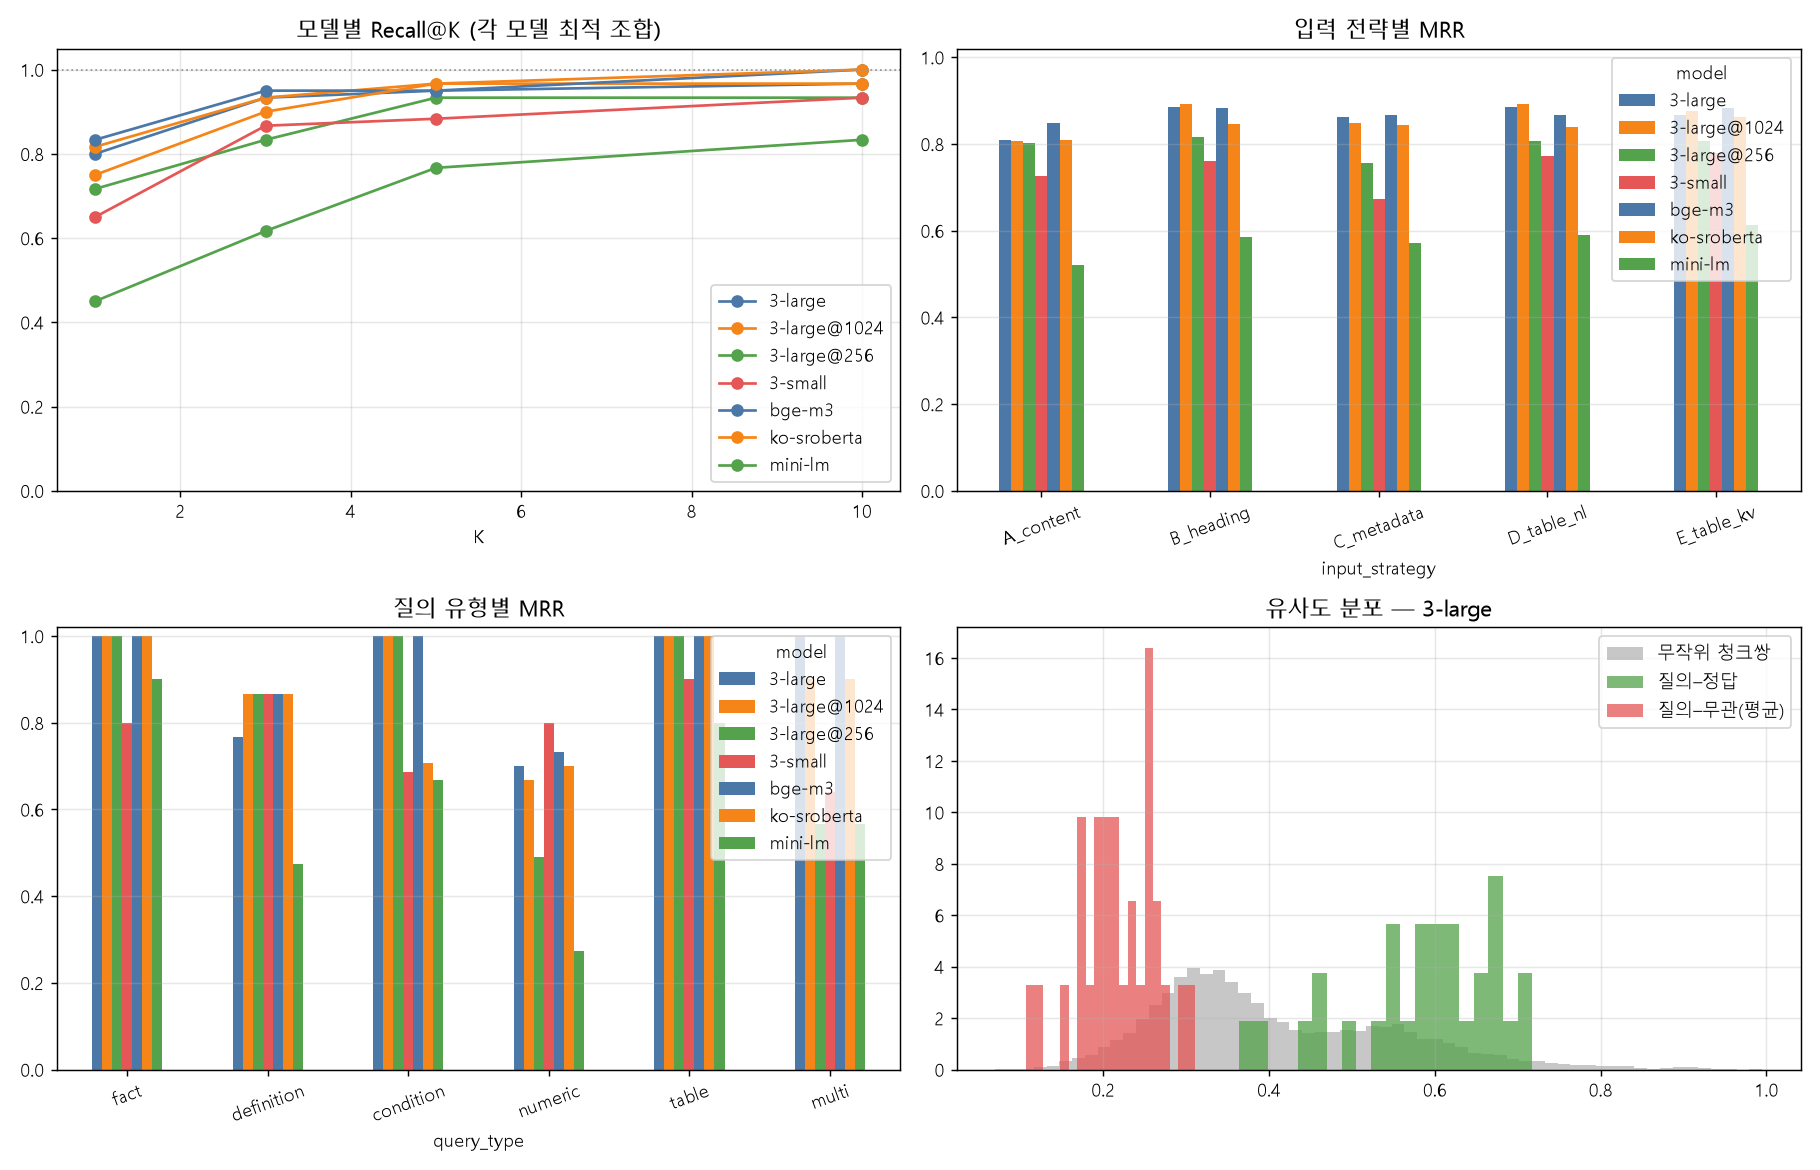

In [28]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib import font_manager

for cand in ("Malgun Gothic", "NanumGothic", "AppleGothic"):
    if any(cand == f.name for f in font_manager.fontManager.ttflist):
        plt.rcParams["font.family"] = cand
        break
plt.rcParams["axes.unicode_minus"] = False

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
C = ["#4C78A8", "#F58518", "#54A24B", "#E45756"]

# ① 모델별 Recall@K — 천장에 닿는 지점이 보이도록
ax = axes[0][0]
for i, m in enumerate(run.model.unique()):
    b = pick_best(run, m)
    ax.plot([1, 3, 5, 10], [b[f"recall@{k}"] for k in TOP_KS], "o-", color=C[i % 4], label=m)
ax.axhline(1.0, color="#999", ls=":", lw=1)
ax.set_title("모델별 Recall@K (각 모델 최적 조합)"); ax.set_xlabel("K"); ax.set_ylim(0, 1.05)
ax.legend(); ax.grid(alpha=.3)

# ② 입력 전략별 — 변별력이 남은 MRR로
ax = axes[0][1]
piv = run[run.query_strategy == "Q_raw"].pivot(index="input_strategy", columns="model", values="mrr")
piv.plot(kind="bar", ax=ax, color=C[:piv.shape[1]], rot=20)
ax.set_title("입력 전략별 MRR"); ax.set_ylim(0, 1.02); ax.grid(alpha=.3, axis="y")

# ③ 질의 유형별
ax = axes[1][0]
QTYPE_MRR.plot(kind="bar", ax=ax, color=C[:QTYPE_MRR.shape[1]], rot=20)
ax.set_title("질의 유형별 MRR"); ax.set_ylim(0, 1.02); ax.grid(alpha=.3, axis="y")

# ④ 유사도 분포 (정답 vs 무관)
ax = axes[1][1]
top = BEST.model
g = GAP_DF[GAP_DF.model == top]
ax.hist(SIM_SAMPLES[top], bins=60, alpha=.55, color="#999999", density=True, label="무작위 청크쌍")
ax.hist(g["relevant_max"], bins=20, alpha=.75, color="#54A24B", density=True, label="질의–정답")
ax.hist(g["irrelevant_mean"], bins=20, alpha=.75, color="#E45756", density=True, label="질의–무관(평균)")
ax.set_title(f"유사도 분포 — {top}"); ax.legend(); ax.grid(alpha=.3)

plt.tight_layout()
plt.savefig(RESULT_DIR / "embedding_charts.png", dpi=130)
plt.close()
from IPython.display import Image
display(Image(str(RESULT_DIR / "embedding_charts.png")))

---
## 16. 최종 전략 선정

**최고 점수 하나로 정하지 않는다**(평가 원칙 §23). 잰 항목만 표에 올리고, 못 잰 항목은
`N/A`로 남겨 판단 근거에서 뺀다 — 안 잰 것을 가중치에 넣으면 그 순간 점수가 허구가 된다.

In [29]:
decision = []
for m in run.model.unique():
    b = pick_best(run, m)
    nq = sel[(sel.model == m) & (sel.query_type == "numeric")]["recall@5"].mean()
    spec = next(s for s in AVAILABLE if s.key == m)
    trunc = TRUNC_DF[TRUNC_DF.model == m].iloc[0]
    v = per_query_metric(m)
    lo, hi = bootstrap_ci(v)
    decision.append({
        "model": m, "역할": "후보" if m in CANDIDATE_KEYS else "기준선", "dim": spec.dim,
        "MRR": round(b["mrr"], 3), "MRR 95%CI": f"[{lo:.2f}, {hi:.2f}]",
        "Recall@1": round(b["recall@1"], 3), "Recall@5": round(b["recall@5"], 3),
        "Table Recall@5": round(table_recall(m), 3), "Numeric Recall@5": round(float(nq), 3),
        "유사도 Gap": round(float(GAP_DF[GAP_DF.model == m]["gap"].mean()), 3),
        "절단률": trunc["절단률"],
        "처리량(texts/s)": round(float(ENC_DF[ENC_DF.model == m]["texts_per_sec"].mean()), 1),
        "과금 토큰": int(ENC_DF[ENC_DF.model == m]["billed_tokens"].sum()) or "—",
        "API 비용": (f"${ENC_DF[ENC_DF.model == m]['billed_tokens'].sum() / 1e6 * USD_PER_1M_TOKENS[spec.model_id]:.4f}"
                    if spec.model_id in USD_PER_1M_TOKENS else ("N/A (단가 미입력)" if not spec.local else "—")),
        "인프라": "GPU 자체 서빙" if spec.local else f"API ({spec.provider})",
    })
DECISION = pd.DataFrame(decision).sort_values(["역할", "MRR"], ascending=[True, False])
display(DECISION)
DECISION.to_csv(RESULT_DIR / "decision_matrix.csv", index=False, encoding="utf-8-sig")

# 승자는 **후보군에서만** 나온다. 기준선이 더 높아도 그건 채택 결정이 아니라 참고다.
cands = DECISION[DECISION["역할"] == "후보"].sort_values("MRR", ascending=False)

# 모델에도 동률 규칙을 적용한다(§16-1과 같은 TIE_EPS). 성능이 같다면 **차원이 작은 쪽**이 낫다
# — 벡터 저장량·검색 비용이 차원에 정비례하므로, 같은 값이면 싼 것을 고르는 게 기본값이다.
TIE_EPS_MODEL = 0.01
tied = cands[cands["MRR"] >= cands["MRR"].max() - TIE_EPS_MODEL]
WINNER = tied.sort_values("dim").iloc[0]
if len(tied) > 1:
    top = cands.iloc[0]
    print(f"동률 모델 {list(tied.model)} (ΔMRR<{TIE_EPS_MODEL}) → 차원이 가장 작은 "
          f"`{WINNER.model}`({WINNER.dim}차원) 선정")
    print(f"   MRR 최고는 `{top.model}`({top.MRR}, {top.dim}차원)이지만 차이 "
          f"{top.MRR - WINNER.MRR:+.4f}는 질의 30건 벤치마크에서 0이다. "
          f"Recall@1은 오히려 {WINNER.model}이 {WINNER['Recall@1']:.3f} vs {top['Recall@1']:.3f}")
_top_overall = DECISION.sort_values("MRR", ascending=False).iloc[0]
if _top_overall.model != WINNER.model:
    print(f"ℹ️ 전체 최고는 기준선 `{_top_overall.model}`(MRR {_top_overall.MRR}) 이지만, "
          f"공급자가 `{PREFER_PROVIDER}`로 결정돼 있어 후보군 최고 `{WINNER.model}`"
          f"(MRR {WINNER.MRR})를 선정한다. 격차 {_top_overall.MRR - WINNER.MRR:+.3f}는 "
          "재검토 트리거로 기록해 둘 것")
w_spec = next(s for s in AVAILABLE if s.key == WINNER.model)
w_best = pick_best(run, WINNER.model)

# §12의 BEST는 '점수 1위', 여기의 WINNER는 '동률이면 싼 쪽' 규칙까지 적용한 결과다.
# 둘이 달라질 수 있지만, **동률 밴드 밖으로 벗어나면 안 된다** — 그건 규칙이 아니라 사고다.
assert WINNER.model in set(cands.model), "❌ 승자가 후보군 밖이다"
assert WINNER.MRR >= cands["MRR"].max() - TIE_EPS_MODEL, \
    f"❌ 승자 MRR {WINNER.MRR}이 동률 밴드(최고 {cands['MRR'].max()} − {TIE_EPS_MODEL}) 밖이다"
if WINNER.model != BEST.model:
    print(f"※ §12 점수 1위는 `{BEST.model}`, 최종 선정은 `{WINNER.model}` — 동률 규칙 적용 결과다")
print(f"\n1차 선정: {WINNER.model} / 입력 {w_best.input_strategy} / 질의 {w_best.query_strategy}")

,model,역할,dim,MRR,MRR 95%CI,Recall@1,Recall@5,Table Recall@5,Numeric Recall@5,유사도 Gap,절단률,처리량(texts/s),과금 토큰,API 비용,인프라
4,bge-m3,기준선,1024,0.933,"[0.85, 1.00]",0.833,0.950,1.00,0.8,0.303,0.5%,695.9,—,—,GPU 자체 서빙
5,ko-sroberta,기준선,768,0.862,"[0.76, 0.96]",0.750,0.967,1.00,0.8,0.359,73.0%,2011.6,—,—,GPU 자체 서빙
6,mini-lm,기준선,384,0.614,"[0.47, 0.76]",0.450,0.767,0.75,0.8,0.315,74.3%,2601.0,—,—,GPU 자체 서빙
0,3-large,후보,3072,0.911,"[0.82, 0.98]",0.800,0.950,1.00,0.8,0.365,N/A (상한 미확인),47.0,1839427,N/A (단가 미입력),API (OpenAI)
1,3-large@1024,후보,1024,0.906,"[0.81, 0.98]",0.817,0.967,1.00,0.8,0.369,N/A (상한 미확인),73.5,1839427,N/A (단가 미입력),API (OpenAI)
2,3-large@256,후보,256,0.821,"[0.69, 0.93]",0.717,0.933,1.00,0.8,0.368,N/A (상한 미확인),88.6,1839427,N/A (단가 미입력),API (OpenAI)
3,3-small,후보,1536,0.782,"[0.65, 0.90]",0.650,0.883,1.00,0.8,0.293,N/A (상한 미확인),62.4,1839427,N/A (단가 미입력),API (OpenAI)


동률 모델 ['3-large', '3-large@1024'] (ΔMRR<0.01) → 차원이 가장 작은 `3-large@1024`(1024차원) 선정
   MRR 최고는 `3-large`(0.911, 3072차원)이지만 차이 +0.0050는 질의 30건 벤치마크에서 0이다. Recall@1은 오히려 3-large@1024이 0.817 vs 0.800
ℹ️ 전체 최고는 기준선 `bge-m3`(MRR 0.933) 이지만, 공급자가 `OpenAI`로 결정돼 있어 후보군 최고 `3-large@1024`(MRR 0.906)를 선정한다. 격차 +0.027는 재검토 트리거로 기록해 둘 것
※ §12 점수 1위는 `3-large`, 최종 선정은 `3-large@1024` — 동률 규칙 적용 결과다

1차 선정: 3-large@1024 / 입력 D_table_nl / 질의 Q_ctx


### 16-1. 동률 구간에서는 바꾸지 않는다

📏 `bge-m3`의 상위 세 조합은 MRR `0.9333 / 0.9325 / 0.9325`다 — **차이 0.0008**. 질의 1건이
3.3%p인 벤치마크에서 이건 0이다. 이 차이로 "표를 헤더 반복 형태로 바꾸자"고 결론 내면
**잡음을 근거로 구현을 바꾸는** 것이 된다.

그래서 규칙을 하나 더 둔다.

> **최고값과 `TIE_EPS`(0.01) 안에 있는 조합은 동률로 본다. 동률이면 이미 구현된 쪽
> (`B_heading` = `Chunk.embedding_text()`)을 유지한다.**

바꿀 이유를 데이터가 대지 못하면 바꾸지 않는 것이 기본값이다. 반대로 **동률을 넘는 차이는
채택한다** — 아래에서 질의 전략이 그 경우다.

In [30]:
TIE_EPS = 0.01
INCUMBENT_INPUT = "B_heading"       # 현재 Chunk.embedding_text() 의 동작
INCUMBENT_QUERY = "Q_raw"           # 질의를 손대지 않는 쪽


def resolve(cands: pd.DataFrame, column: str, incumbent: str) -> tuple[str, list[str], str]:
    tie = cands[cands["mrr"] >= cands["mrr"].max() - TIE_EPS]
    names = sorted(set(tie[column]))
    if incumbent in names:
        return incumbent, names, f"동률({len(names)}개, Δ<{TIE_EPS}) → 기존 `{incumbent}` 유지"
    top = cands.sort_values("mrr", ascending=False).iloc[0][column]
    delta = cands["mrr"].max() - cands[cands[column] == incumbent]["mrr"].max()
    return top, names, f"`{top}` 채택 (기존 `{incumbent}` 대비 ΔMRR={delta:+.3f} > {TIE_EPS})"


mine = run[run.model == WINNER.model]
q_pick, q_tie, q_why = resolve(mine[mine.input_strategy == w_best.input_strategy],
                               "query_strategy", INCUMBENT_QUERY)
i_pick, i_tie, i_why = resolve(mine[mine.query_strategy == q_pick], "input_strategy", INCUMBENT_INPUT)
print(f"질의 전략: {q_why}   (동률권 {q_tie})")
print(f"입력 전략: {i_why}   (동률권 {i_tie})")

FINAL = mine[(mine.input_strategy == i_pick) & (mine.query_strategy == q_pick)].iloc[0]
assert FINAL["mrr"] >= mine["mrr"].max() - TIE_EPS, "❌ 최종 조합이 동률권 밖이다"
w_best = FINAL

# 질의 전략 채택의 근거 — 짝지은 부트스트랩
if q_pick != INCUMBENT_QUERY:
    def pq(qs):
        s = PER_QUERY_DF[(PER_QUERY_DF.model == WINNER.model)
                         & (PER_QUERY_DF.input_strategy == i_pick)
                         & (PER_QUERY_DF.query_strategy == qs)]
        return s.set_index("query_id").loc[[g[0] for g in GOLD], "mrr"].to_numpy()
    d = pq(q_pick) - pq(INCUMBENT_QUERY)
    idx = np.random.default_rng(SEED).integers(0, len(d), size=(5000, len(d)))
    dd = d[idx].mean(axis=1)
    lo, hi = float(np.quantile(dd, .025)), float(np.quantile(dd, .975))
    print(f"   📏 {q_pick} − {INCUMBENT_QUERY}: ΔMRR={d.mean():+.3f} 95% CI [{lo:+.3f}, {hi:+.3f}]"
          + (" → 우세" if lo > 0 else " → ⚠️ 잡음과 구분 불가 (그래도 채택하려면 근거가 더 필요하다)"))

print(f"\n✅ 최종: {WINNER.model} / 입력 {w_best.input_strategy} / 질의 {w_best.query_strategy}"
      f"  MRR={w_best['mrr']:.3f} Recall@1={w_best['recall@1']:.3f} Recall@5={w_best['recall@5']:.3f}")

질의 전략: `Q_ctx` 채택 (기존 `Q_raw` 대비 ΔMRR=+0.014 > 0.01)   (동률권 ['Q_ctx'])
입력 전략: 동률(3개, Δ<0.01) → 기존 `B_heading` 유지   (동률권 ['B_heading', 'D_table_nl', 'E_table_kv'])
   📏 Q_ctx − Q_raw: ΔMRR=+0.014 95% CI [-0.014, +0.053] → ⚠️ 잡음과 구분 불가 (그래도 채택하려면 근거가 더 필요하다)

✅ 최종: 3-large@1024 / 입력 B_heading / 질의 Q_ctx  MRR=0.906 Recall@1=0.817 Recall@5=0.950


#### 절단률이 73%인데 성능이 나쁘지 않은 모델을 어떻게 읽을 것인가

`ko-sroberta`·`mini-lm`은 공식 `max_seq_length`가 128토큰이라 청크의 4분의 3이 잘린다.
그런데도 `ko-sroberta`가 상위권이다. 이건 모델이 좋아서가 아니라 **이 코퍼스에서 검색 신호가
앞부분에 몰려 있다**는 뜻이다 — 계층 헤더 3줄 + 조 제목 + 첫 문장이면 대개 어느 조문인지
갈린다(청킹 전략 §5가 헤더를 본문에 박아 둔 이유이기도 하다).

**그래서 절단률은 "지금 점수"가 아니라 "나중에 깨질 위험"으로 읽어야 한다.** 뒷부분을 봐야
갈리는 질의(같은 조 안의 여러 항을 구분해야 하는 경우, 긴 법령 조문)에서 먼저 무너진다.
현재 정답셋 30건에는 그런 질의가 적다 — 이것이 §18에 남기는 미결 항목이다.

### 16-2. 최종 순위 — 1등과 구분되는가

앞 절들의 결론을 **한 표**로 모은다. 핵심은 점수 순서가 아니라 **어디까지가 같은 성능인가** 다:
1위와의 ΔMRR을 짝지은 부트스트랩으로 재서, **CI가 0을 포함하면 `≈ 1위`(구분 불가)** 로 표시한다.

그 밴드 안에서는 점수로 고르면 안 되고, **차원·처리량·운영 조건**으로 골라야 한다.

In [31]:
_lead = DECISION.sort_values("MRR", ascending=False).iloc[0]
_lead_v = per_query_metric(_lead.model)

rank_rows = []
for i, (_, r) in enumerate(DECISION.sort_values("MRR", ascending=False).iterrows(), 1):
    spec = next(s for s in AVAILABLE if s.key == r.model)
    if r.model == _lead.model:
        verdict, ci = "— (1위)", "—"
    else:
        d = _lead_v - per_query_metric(r.model)
        idx = np.random.default_rng(SEED).integers(0, len(d), size=(5000, len(d)))
        dd = d[idx].mean(axis=1)
        lo, hi = float(np.quantile(dd, .025)), float(np.quantile(dd, .975))
        verdict = "≈ 1위 (구분 불가)" if lo <= 0 <= hi else "열위"
        ci = f"[{lo:+.3f}, {hi:+.3f}]"
    rank_rows.append({
        "순위": i, "model": r.model, "역할": r["역할"], "dim": r.dim,
        "MRR": r.MRR, "Recall@1": r["Recall@1"], "Recall@5": r["Recall@5"],
        "1위와의 ΔMRR 95%CI": ci, "판정": verdict,
        "처리량(texts/s)": r["처리량(texts/s)"],
        "벡터 MB": round(len(INDEX) * spec.dim * 4 / 1e6, 2),
        "선정": "✅" if r.model == WINNER.model else "",
    })
RANKING = pd.DataFrame(rank_rows)
display(RANKING)
RANKING.to_csv(RESULT_DIR / "ranking.csv", index=False, encoding="utf-8-sig")

_band = RANKING[RANKING["판정"].str.startswith(("—", "≈"))]
print(f"\n📏 1위와 구분되지 않는 모델 {len(_band)}종: {list(_band.model)}")
print(f"   → 이 밴드 안에서는 점수가 아니라 차원·처리량·운영 조건으로 고른다.")
print(f"   선정: {WINNER.model} ({WINNER.dim}차원) — "
      f"{'밴드 안' if WINNER.model in set(_band.model) else '⚠️ 밴드 밖'}, "
      f"공급자 제약({PREFER_PROVIDER}) 적용 결과")

,순위,model,역할,dim,MRR,Recall@1,Recall@5,1위와의 ΔMRR 95%CI,판정,처리량(texts/s),벡터 MB,선정
0,1,bge-m3,기준선,1024,0.933,0.833,0.950,—,— (1위),695.9,3.27,
1,2,3-large,후보,3072,0.911,0.800,0.950,"[-0.011, +0.078]",≈ 1위 (구분 불가),47.0,9.82,
2,3,3-large@1024,후보,1024,0.906,0.817,0.967,"[-0.044, +0.100]",≈ 1위 (구분 불가),73.5,3.27,✅
3,4,ko-sroberta,기준선,768,0.862,0.750,0.967,"[-0.022, +0.168]",≈ 1위 (구분 불가),2011.6,2.45,
4,5,3-large@256,후보,256,0.821,0.717,0.933,"[+0.003, +0.233]",열위,88.6,0.82,
5,6,3-small,후보,1536,0.782,0.650,0.883,"[+0.022, +0.291]",열위,62.4,4.91,
6,7,mini-lm,기준선,384,0.614,0.450,0.767,"[+0.171, +0.473]",열위,2601.0,1.23,



📏 1위와 구분되지 않는 모델 4종: ['bge-m3', '3-large', '3-large@1024', 'ko-sroberta']
   → 이 밴드 안에서는 점수가 아니라 차원·처리량·운영 조건으로 고른다.
   선정: 3-large@1024 (1024차원) — 밴드 안, 공급자 제약(OpenAI) 적용 결과


### 16-4. 사람 검수 시트

내재 지표와 Recall은 "규칙을 지켰는가"와 "정답을 찾았는가"만 잰다. **정답셋 자체가 타당한가**는
사람이 봐야 한다. 청킹 노트북이 `review_samples.csv`를 떨군 것과 같은 이유다.

In [32]:
review = []
V = DOC_VECS[(WINNER.model, w_best.input_strategy)]
Q = QRY_VECS[(WINNER.model, w_best.query_strategy)]
S = Q @ V.T
for qi, (qid, qt, q, rel) in enumerate(GOLD):
    top5 = np.argsort(-S[qi])[:5]
    review.append({
        "query_id": qid, "query_type": qt, "query": q,
        "정답 조문": " | ".join(rel),
        "검색 1위": INDEX[top5[0]].citation, "1위 점수": round(float(S[qi, top5[0]]), 3),
        "top5 조문": " | ".join(dict.fromkeys(INDEX[p].citation for p in top5)),
        "Q1 정답이 타당한가(O/X)": "", "Q2 1위가 실제로 답인가(O/X)": "", "메모": "",
    })
REVIEW_DF = pd.DataFrame(review)
REVIEW_DF.to_csv(RESULT_DIR / "review_samples.csv", index=False, encoding="utf-8-sig")
display(REVIEW_DF.head(10)[["query_id", "query_type", "정답 조문", "검색 1위", "1위 점수"]])
print(f"\n검수 시트 {len(REVIEW_DF)}행 → {RESULT_DIR / 'review_samples.csv'}")

,query_id,query_type,정답 조문,검색 1위,1위 점수
0,F01,fact,법인카드_사용규정|제7조,법인카드_사용규정 제7조,0.778
1,F02,fact,법인카드_사용규정|제5조,법인카드_사용규정 제5조,0.697
2,F03,fact,출장비_사용규정|제4조,출장비_사용규정 제4조 제1~3항,0.789
3,F04,fact,회식_운영규정|제10조,회식_운영규정 제10조,0.760
4,F05,fact,법인카드_사용규정|제16조,법인카드_사용규정 제16조,0.497
5,D01,definition,업무추진비_사용규정|제2조,업무추진비_사용규정 제2조 제1~3항,0.620
6,D02,definition,출장비_사용규정|제2조,출장비_사용규정 제2조,0.758
7,D03,definition,법인카드_사용규정|제2조,법인카드_사용규정 제2조,0.688
8,D04,definition,회식_운영규정|제2조,회식_운영규정 제5조,0.717
9,D05,definition,법인카드_사용규정|제15조,법인카드_사용규정 제15조,0.680



검수 시트 30행 → D:\project\SKN29-FINAL-1TEAM\docling_eval\output\embedding\results\review_samples.csv


---
## 17. 벡터 저장 · Vector DB 구조

**CSV에 벡터를 문자열로 넣지 않는다**(프롬프트 §20). `.npy` 바이너리 + 메타데이터 CSV로 나눈다.
기본값은 **선정 조합만** 저장한다 — 전 그리드(모델×전략)를 다 저장하면 수십 MB가 되고,
이 노트북을 다시 돌리면 그대로 재생되므로 저장할 이유가 없다(`SAVE_ALL_VECTORS=True`로 전환 가능).

메타데이터는 지어내지 않고 **`Chunk.to_chroma()`가 실제로 내보내는 것**을 그대로 쓴다.
컬렉션 매핑은 청킹 전략 §9의 계약을 따른다 — `policy_docs`←REGULATION / `tax_refs`←LAW.

In [33]:
saved = []
targets = ([(m, s) for m in run.model.unique() for s in STRATEGIES] if SAVE_ALL_VECTORS
           else [(WINNER.model, w_best.input_strategy)])

keep = {f"{m}__{s}.npy" for m, s in targets}
for stale in VECTOR_DIR.glob("*.npy"):                     # 이전 실행이 남긴 벡터를 끌고 가지 않는다
    if stale.name not in keep:
        stale.unlink()
        print(f"   ✗ 삭제(이전 실행 잔재) {stale.name}")

for m, s in targets:
    path = VECTOR_DIR / f"{m}__{s}.npy"
    np.save(path, DOC_VECS[(m, s)].astype(np.float16))     # float16 — 코사인 순위에 영향 미미
    saved.append({"file": path.name, "model": m, "input_strategy": s,
                  "shape": str(DOC_VECS[(m, s)].shape), "MB": round(path.stat().st_size / 1e6, 2)})
display(pd.DataFrame(saved))

meta_rows = []
for c in INDEX:
    if hasattr(c, "to_chroma"):
        cid, document, meta = c.to_chroma()
    else:
        cid, document, meta = c.chunk_id, c.context_text(), {"doc_name": c.doc_name}
    meta_rows.append({"chunk_id": cid, "document_chars": len(document),
                      "embedding_chars": len(build_input(c, w_best.input_strategy)), **meta})
META_DF = pd.DataFrame(meta_rows)
META_DF.to_csv(VECTOR_DIR / "embedding_metadata.csv", index=False, encoding="utf-8-sig")
print(f"메타데이터 {META_DF.shape[0]}행 × {META_DF.shape[1]}열 → embedding_metadata.csv")
display(META_DF.head(3).T)

,file,model,input_strategy,shape,MB
0,3-large@1024__B_heading.npy,3-large@1024,B_heading,"(799, 1024)",1.64


메타데이터 799행 × 34열 → embedding_metadata.csv


,0,1,2
chunk_id,dump:법인카드_사용규정#s002#01,dump:법인카드_사용규정#s002#02,dump:법인카드_사용규정#c01a001#01
document_chars,150,391,220
embedding_chars,150,391,220
doc_id,dump:법인카드_사용규정,dump:법인카드_사용규정,dump:법인카드_사용규정
doc_name,법인카드_사용규정,법인카드_사용규정,법인카드_사용규정
profile,REGULATION,REGULATION,REGULATION
chunk_type,table,section,article
chunk_role,child,child,atomic
citation,법인카드_사용규정,법인카드_사용규정,법인카드_사용규정 제1조
page_start,1,1,2


In [34]:
COLLECTION_OF = {"REGULATION": "policy_docs", "LAW": "tax_refs"}
counts = Counter(COLLECTION_OF.get(getattr(c, "profile", ""), "미정(DIAGRAM 등)") for c in INDEX)

SCHEMA = {
    "vector_db": "Chroma",
    "distance": "cosine",
    "collection_config": {"hnsw:space": "cosine"},
    "embedding": {
        "provider": w_spec.provider,
        "model": w_spec.model_id, "dim": int(w_spec.dim),
        # API 모델은 풀링·상한이 우리 소관이 아니다 — 모르는 것은 null로 둔다
        "dimensions_param": w_spec.dimensions,
        "pooling": w_spec.pooling if w_spec.local else None,
        "normalize": True,
        "max_tokens": int(w_spec.max_tokens) if w_spec.max_tokens else None,
        "batch_size": BATCH_SIZE if w_spec.local else API_BATCH_SIZE,
        "document_input": w_best.input_strategy, "query_input": w_best.query_strategy,
    },
    "collections": {k: v for k, v in counts.items()},
    "upsert_contract": {
        "ids": "Chunk.chunk_id",
        "documents": "Chunk.context_text()   # LLM에 주는 전문",
        "embeddings": "직접 계산한 벡터 (Chunk.embedding_text() 기반)",
        "metadatas": "Chunk.to_chroma()[2]  # 스칼라만",
        "주의": "컬렉션에 embedding_function 을 맡기지 말 것 — 임베딩 텍스트와 저장 문서가 다르다",
    },
    "search_contract": {
        "1_filter": 'where={"chunk_role": {"$ne": "parent"}}',
        "2_expand": "히트의 parent_chunk_id 로 부모 본문을 붙여 LLM 컨텍스트 구성",
        "3_neighbor": "필요 시 prev/next_chunk_id 로 이웃 1개씩",
    },
}
(RESULT_DIR / "vector_store_schema.json").write_text(
    json.dumps(SCHEMA, ensure_ascii=False, indent=2), encoding="utf-8")
print(json.dumps(SCHEMA, ensure_ascii=False, indent=2))

{
  "vector_db": "Chroma",
  "distance": "cosine",
  "collection_config": {
    "hnsw:space": "cosine"
  },
  "embedding": {
    "provider": "OpenAI",
    "model": "text-embedding-3-large",
    "dim": 1024,
    "dimensions_param": 1024,
    "pooling": null,
    "normalize": true,
    "max_tokens": null,
    "batch_size": 128,
    "document_input": "B_heading",
    "query_input": "Q_ctx"
  },
  "collections": {
    "policy_docs": 90,
    "미정(DIAGRAM 등)": 48,
    "tax_refs": 661
  },
  "upsert_contract": {
    "ids": "Chunk.chunk_id",
    "documents": "Chunk.context_text()   # LLM에 주는 전문",
    "embeddings": "직접 계산한 벡터 (Chunk.embedding_text() 기반)",
    "metadatas": "Chunk.to_chroma()[2]  # 스칼라만",
    "주의": "컬렉션에 embedding_function 을 맡기지 말 것 — 임베딩 텍스트와 저장 문서가 다르다"
  },
  "search_contract": {
    "1_filter": "where={\"chunk_role\": {\"$ne\": \"parent\"}}",
    "2_expand": "히트의 parent_chunk_id 로 부모 본문을 붙여 LLM 컨텍스트 구성",
    "3_neighbor": "필요 시 prev/next_chunk_id 로 이웃 1개씩"
  }
}


---
## 18. 최종 리포트

In [35]:
def fmt(v, nd=3):
    return "N/A" if v is None or (isinstance(v, float) and np.isnan(v)) else f"{v:.{nd}f}"


num_r5 = float(sel[(sel.model == WINNER.model) & (sel.query_type == "numeric")]["recall@5"].mean())
tbl_r5 = table_recall(WINNER.model)

banner = f"""
==================================================
        EMBEDDING STRATEGY EVALUATION
==================================================

Recommended Model
    : {w_spec.model_id}

Embedding Dimension
    : {w_spec.dim}

Document Input Strategy
    : {w_best.input_strategy} ({STRAT_LABEL[w_best.input_strategy]})

Query Input Strategy
    : {w_best.query_strategy}

--------------------------------------------------

Recall@5
    : {fmt(w_best['recall@5'])}

MRR
    : {fmt(w_best['mrr'])}

Table Recall@5
    : {fmt(tbl_r5)}

Numeric Query Recall@5
    : {fmt(num_r5)}

--------------------------------------------------

Final Recommendation
    : {w_spec.model_id} + {w_best.input_strategy} + cosine / Chroma

Reason
    : 아래 리포트 §4 참조 (측정 근거 포함)
==================================================
"""
print(banner)


        EMBEDDING STRATEGY EVALUATION

Recommended Model
    : text-embedding-3-large

Embedding Dimension
    : 1024

Document Input Strategy
    : B_heading (Heading + Content)

Query Input Strategy
    : Q_ctx

--------------------------------------------------

Recall@5
    : 0.950

MRR
    : 0.906

Table Recall@5
    : 1.000

Numeric Query Recall@5
    : 0.800

--------------------------------------------------

Final Recommendation
    : text-embedding-3-large + B_heading + cosine / Chroma

Reason
    : 아래 리포트 §4 참조 (측정 근거 포함)



In [36]:
lines = []
W = lines.append
W("# 임베딩 전략 평가 리포트\n")
W(f"> 생성: `docling_eval/docling_embedding_strategy.ipynb` · 코퍼스 {len({c.doc_name for c in INDEX})}종 "
  f"{len(INDEX):,}청크 · 질의 {len(GOLD)}건 · 장치 {DEVICE}\n")
W("> 📏 는 이 노트북이 실행 중 측정한 값이다. 측정하지 않은 항목은 `N/A`로 둔다.\n")

W("\n## 0. 한눈에 — 어떤 모델이 제일 나은가\n")
W(f"> **점수 1위는 `{_lead.model}`(MRR {fmt(_lead.MRR)}). 다만 상위 {len(_band)}종은 "
  f"통계적으로 구분되지 않는다.** 공급자가 `{PREFER_PROVIDER}`로 결정돼 있어 그 밴드 안의 "
  f"OpenAI 모델 중 **차원이 가장 작은 `{WINNER.model}`** 를 선정했다.\n")
W(RANKING.to_markdown(index=False))
W(f"\n- **`판정` 열 읽는 법**: 1위와의 ΔMRR을 짝지은 부트스트랩(5,000회)으로 재서 "
  f"**95% CI가 0을 포함하면 `≈ 1위`** 다 — 질의 {len(GOLD)}건 벤치마크에서 그 차이는 0이라는 뜻이다. "
  "이 밴드 안에서는 점수로 고르면 안 되고 **차원·처리량·운영 조건**으로 골라야 한다.")
W(f"- **밴드 밖은 실제로 나쁘다**: `열위`로 찍힌 모델은 CI가 0을 넘지 않으므로 "
  "정답셋을 바꿔도 뒤집히기 어렵다.")
if _lead["역할"] != "후보":
    W(f"- ⚠️ **1위 `{_lead.model}`는 후보가 아니라 기준선(자체 서빙)이다.** 이 표는 "
      f"`{PREFER_PROVIDER}` 채택을 뒷받침하지 않는다 — 채택 근거는 점수 밖에 있어야 하고, "
      f"처리량은 {_lead['처리량(texts/s)']:.0f} vs {WINNER['처리량(texts/s)']:.0f} texts/s로 "
      f"기준선이 {_lead['처리량(texts/s)'] / max(WINNER['처리량(texts/s)'], 1e-9):.0f}배 빠르다.")
W(f"- ⚠️ **지금 정답셋으로는 밴드 안을 더 못 가른다**: 📏 `Recall@5`가 {len(run)}개 조합 중 "
  f"{sat}개에서 1.000에 닿았다(천장). 1~{len(_band)}위 중 무엇이 진짜 나은지 답하려면 "
  "**정답셋 난이도 보강이 먼저다**(§10).")

W("\n## 1. 결론\n")
W(f"| 항목 | 값 |\n|---|---|")
W(f"| Embedding Model | `{w_spec.model_id}` |")
W(f"| Embedding Dimension | {w_spec.dim} |")
W(f"| Document Input | `{w_best.input_strategy}` — {STRAT_LABEL[w_best.input_strategy]} |")
W(f"| Query Input | `{w_best.query_strategy}` |")
W(f"| Table 처리 | {'행 단위 자연어 변환' if w_best.input_strategy == 'D_table_nl' else ('헤더 반복' if w_best.input_strategy == 'E_table_kv' else '마크다운 원형 + 계층 헤더')} |")
W(f"| Metadata | 검색 필터·컨텍스트 확장용 (`Chunk.to_chroma()`) |")
W(f"| 공급자 | {w_spec.provider} ({'자체 서빙' if w_spec.local else 'API'}) |")
if w_spec.dimensions:
    W(f"| `dimensions` 파라미터 | **{w_spec.dimensions}** (네이티브에서 축소) |")
W(f"| Pooling / Normalize | {(w_spec.pooling if w_spec.local else 'N/A (API)')} / L2 |")
W(f"| Distance Metric | Cosine |")
W(f"| Batch Size | {BATCH_SIZE if w_spec.local else API_BATCH_SIZE} |")
W(f"| Vector DB | Chroma (`hnsw:space=cosine`) |")
W(f"\n선정 규칙: **{' → '.join(PRIMARY)}**, 최고값과 `TIE_EPS={TIE_EPS}` 안이면 동률로 보고 "
  f"**이미 구현된 쪽을 유지**한다.\n")
W(f"- 입력 전략: {i_why} · 동률권 `{'`, `'.join(i_tie)}`")
W(f"- 질의 전략: {q_why} · 동률권 `{'`, `'.join(q_tie)}`")

W("\n## 2. 실측 성능\n")
W(f"| 지표 | 값 |\n|---|---:|")
for k in TOP_KS:
    W(f"| Recall@{k} | {fmt(w_best[f'recall@{k}'])} |")
    W(f"| HitRate@{k} | {fmt(w_best[f'hit@{k}'])} |")
W(f"| MRR | {fmt(w_best['mrr'])} |")
W(f"| nDCG@{NDCG_K} | {fmt(w_best[f'ndcg@{NDCG_K}'])} |")
W(f"| Table Recall@5 | {fmt(tbl_r5)} |")
W(f"| Numeric Recall@5 | {fmt(num_r5)} |")

W("\n## 3. 모델 비교\n")
W(f"공급자는 **{PREFER_PROVIDER}** 로 결정돼 있다. 후보군 = `{'`, `'.join(CANDIDATE_KEYS)}`, "
  f"나머지는 기준선(참고).\n")
W(COMPARISON.to_markdown(index=False))
if len(DIM_DF):
    W("\n### 3-1. 차원(dimensions) 트레이드오프\n")
    W(DIM_DF.to_markdown(index=False))
if tok_rows:
    W("\n### 3-2. 토큰·비용 (실제 과금 토큰)\n")
    W(TOKEN_DF.to_markdown(index=False))
    if not USD_PER_1M_TOKENS:
        W("\n> 단가 미입력이라 금액은 `N/A`. 공식 가격표 확인 후 `USD_PER_1M_TOKENS`에 넣으면 환산된다.")
W("\n## 4. 입력 전략 비교\n")
W(STRAT_DF.to_markdown(index=False))
W("\n## 5. 질의 유형별\n")
W("Recall@5\n")
W(QTYPE.to_markdown())
W("\nMRR (변별력이 남아 있는 지표)\n")
W(QTYPE_MRR.to_markdown())
W("\n## 6. 절단률 (모델 공식 max_seq_length 기준)\n")
W(TRUNC_DF.to_markdown(index=False))
W("\n## 7. 임베딩 품질\n")
W(QUAL_DF.to_markdown(index=False))
W("\n## 8. 판정 근거\n")
best_strat = STRAT_DF.iloc[0]
W(f"- **선정 기준**: `{' → '.join(PRIMARY)}`. 📏 `recall@5`는 {len(run)}개 조합 중 {sat}개가 "
  f"1.000에 닿아 **변별력이 없어** 선정에서 뺐다(질의 30건이라 1건 = {1 / len(GOLD):.1%}p).")
_rank = DECISION.sort_values("MRR", ascending=False)
W("- **모델**(📏 MRR 내림차순, ★=후보군): "
  + " > ".join(f"{'★' if r['역할'] == '후보' else ''}`{r.model}`({fmt(r['MRR'])})"
               for _, r in _rank.iterrows()))
W("  - Recall@1: " + " > ".join(
    f"`{r.model}`({fmt(r['Recall@1'])})"
    for _, r in DECISION.sort_values("Recall@1", ascending=False).iterrows()))
for m in _rank.model:
    if m == WINNER.model:
        continue
    d = per_query_metric(WINNER.model) - per_query_metric(m)
    idx = np.random.default_rng(SEED).integers(0, len(d), size=(5000, len(d)))
    dd = d[idx].mean(axis=1)
    lo, hi = float(np.quantile(dd, .025)), float(np.quantile(dd, .975))
    W(f"  - 📏 `{WINNER.model}` − `{m}` ΔMRR={d.mean():+.3f}, 95% CI [{lo:+.3f}, {hi:+.3f}]"
      + (" → 우세" if lo > 0 else " → **잡음과 구분 불가**"))
W(f"- **입력 전략**: 📏 평균 MRR 최고 `{best_strat.input_strategy}`({fmt(best_strat['mrr(평균)'])}), "
  f"최저 `{STRAT_DF.iloc[-1].input_strategy}`({fmt(STRAT_DF.iloc[-1]['mrr(평균)'])}) — "
  f"차이 {best_strat['mrr(평균)'] - STRAT_DF.iloc[-1]['mrr(평균)']:.3f}. "
  f"다만 선정 모델 안에서는 상위 {len(i_tie)}개가 동률(Δ<{TIE_EPS})이라 **바꿀 근거가 없다** → {i_why}")
W(f"  - 📏 확실한 것은 **`A_content`(본문만)가 꼴찌**라는 것이다 — 계층 헤더를 임베딩 입력에 "
  f"넣는 것은 평균 MRR을 {STRAT_DF.iloc[0]['mrr(평균)'] - STRAT_DF[STRAT_DF.input_strategy == 'A_content'].iloc[0]['mrr(평균)']:+.3f} "
  "움직인다. 표 표현 방식(마크다운/자연어/헤더반복)의 차이는 그보다 훨씬 작다")
if _top_overall.model != WINNER.model:
    W(f"- ⚠️ **기준선이 더 높다**: 📏 `{_top_overall.model}`(기준선, MRR {fmt(_top_overall.MRR)}) > "
      f"`{WINNER.model}`(후보, MRR {fmt(WINNER.MRR)}), 격차 {_top_overall.MRR - WINNER.MRR:+.3f}. "
      f"공급자가 `{PREFER_PROVIDER}`로 **먼저 결정돼 있어** 후보군 안에서 골랐다 — "
      "이 표는 그 결정을 정당화하지 않는다. 검색 점수만 보면 자체 서빙이 더 낫다는 뜻이고, "
      "채택 근거는 점수 밖(운영 부담·인프라·팀 역량)에 있어야 한다. **재검토 트리거로 기록해 둘 것.**")

if len(tied) > 1:
    _top = cands.iloc[0]
    W(f"- **동률 모델 중 `{WINNER.model}`을 고른 이유**: 후보군에서 "
      f"`{'`, `'.join(tied.model)}` 가 ΔMRR<{TIE_EPS_MODEL}로 **통계적으로 같다**. "
      f"MRR 최고는 `{_top.model}`({fmt(_top.MRR)}, {_top.dim}차원)이지만 격차 "
      f"{_top.MRR - WINNER.MRR:+.4f}는 질의 30건에서 0이고, **Recall@1은 오히려 "
      f"`{WINNER.model}`이 {fmt(WINNER['Recall@1'])} vs {fmt(_top['Recall@1'])}로 앞선다**. "
      f"성능이 같다면 **차원이 작은 쪽**이 낫다 — 벡터 저장량·검색 비용이 차원에 정비례한다"
      + (f" (📏 799청크 기준 {DIM_DF[DIM_DF.model == _top.model]['벡터 MB(799청크·float32)'].iloc[0]:.1f}MB → "
         f"{DIM_DF[DIM_DF.model == WINNER.model]['벡터 MB(799청크·float32)'].iloc[0]:.1f}MB)."
         if len(DIM_DF) and WINNER.model in set(DIM_DF.model) and _top.model in set(DIM_DF.model) else "."))
_others = [m for m in cands.model if m != WINNER.model]
if _others:
    _worst = cands[cands.model.isin(_others)].iloc[-1]
    W(f"- **후보군 하한**: 📏 `{_worst.model}`(MRR {fmt(_worst.MRR)}, {_worst.dim}차원)은 "
      f"선정안보다 {WINNER.MRR - _worst.MRR:+.3f} 낮다 — 차원·모델을 더 줄이면 실제로 잃는다.")
W(f"- **유사도 Gap**: 📏 {WINNER.model} 평균 {fmt(float(GAP_DF[GAP_DF.model == WINNER.model]['gap'].mean()))} "
  f"(정답 최대 vs 무관 평균)")
W(f"- **처리량**: 📏 {WINNER['처리량(texts/s)']} texts/sec"
  + (f" ({DEVICE})" if w_spec.local else f" (API, 배치 {API_BATCH_SIZE})"))
_trunc_local = TRUNC_DF[TRUNC_DF["절단 청크"].notna()]
if len(_trunc_local):
    W("- **절단률**: 📏 " + " · ".join(f"`{r.model}` {r['절단률']}" for _, r in _trunc_local.iterrows())
      + ". 절단률이 큰 모델은 **지금 점수가 아니라 뒷부분을 봐야 갈리는 질의에서 먼저 무너질 위험**"
      "으로 읽어야 한다. 나머지 모델은 공표된 입력 상한을 확인하지 못해 `N/A`로 둔다"
      f" (📏 우리 청크 최대 {int(TRUNC_DF['max'].max())}토큰이라 어느 후보에서도 문제가 되지 않는다).")

W("\n## 9. 측정하지 않은 것 (N/A)\n")
W("| 항목 | 이유 |\n|---|---|")
for s in SKIPPED:
    W(f"| `{s.model_id}` 성능 | {s.note} |")
_api_keys = [s.key for s in AVAILABLE if not s.local]
_billed = int(ENC_DF[ENC_DF.model.isin(_api_keys)]["billed_tokens"].sum()) if _api_keys else 0
if not _billed:
    W("| API 비용 | 이 실행에서 API를 호출하지 않았다. 단가는 공급자 공식 가격표를 확인할 것 |")
elif not USD_PER_1M_TOKENS:
    W(f"| API 비용(금액) | 호출은 했다 — 📏 과금 토큰 {_billed:,}개를 셌다(§3-2). "
      "단가 `USD_PER_1M_TOKENS`가 비어 금액으로 환산하지 못했을 뿐이다 |")
W("| Answer Accuracy | 청킹 품질과 프롬프트 품질이 섞이므로 별건으로 둔다 |")
W("| 정답셋 타당성 | 노트북 저자가 작성했다. `review_samples.csv` 사람 검수 필요 |")
W("\n## 10. 이 결과를 과신하면 안 되는 이유\n")
W(f"1. **질의 30건**이다. 📏 Recall@5는 {sat}/{len(run)} 조합이 1.000으로 이미 천장이고, "
  "MRR 차이도 부트스트랩 CI가 겹치는 구간이 있다(§8). **순위는 방향으로만 읽을 것.**")
W("2. **정답셋을 저자가 만들었다.** 조문을 읽고 질의를 지었으므로 조문의 어휘가 질의에 새어 "
  "들어갔을 수 있다. 어휘가 겹치면 검색은 쉬워진다 — 실제 사용자 질의는 더 어렵다.")
W(f"3. **표 비교는 질의 {len(table_qids)}건**이다. 소수점을 읽지 말 것.")
W("4. **검색 성능만 쟀다.** 이 뒤에 리랭커·하이브리드·프롬프트가 붙으면 순위가 달라질 수 있다.")

W("\n## 11. 산출물\n")
for p in sorted(RESULT_DIR.glob("*")):
    W(f"- `results/{p.name}`")
for p in sorted(VECTOR_DIR.glob("*")):
    W(f"- `vectors/{p.name}`")

(RESULT_DIR / "embedding_strategy_report.md").write_text("\n".join(lines) + "\n", encoding="utf-8")
print(f"리포트 → {RESULT_DIR / 'embedding_strategy_report.md'}  ({len(lines)}줄)")
print("\n".join(lines[:40]))

리포트 → D:\project\SKN29-FINAL-1TEAM\docling_eval\output\embedding\results\embedding_strategy_report.md  (116줄)
# 임베딩 전략 평가 리포트

> 생성: `docling_eval/docling_embedding_strategy.ipynb` · 코퍼스 11종 799청크 · 질의 30건 · 장치 cuda

> 📏 는 이 노트북이 실행 중 측정한 값이다. 측정하지 않은 항목은 `N/A`로 둔다.


## 0. 한눈에 — 어떤 모델이 제일 나은가

> **점수 1위는 `bge-m3`(MRR 0.933). 다만 상위 4종은 통계적으로 구분되지 않는다.** 공급자가 `OpenAI`로 결정돼 있어 그 밴드 안의 OpenAI 모델 중 **차원이 가장 작은 `3-large@1024`** 를 선정했다.

|   순위 | model        | 역할   |   dim |   MRR |   Recall@1 |   Recall@5 | 1위와의 ΔMRR 95%CI   | 판정              |   처리량(texts/s) |   벡터 MB | 선정   |
|-------:|:-------------|:-------|------:|------:|-----------:|-----------:|:---------------------|:------------------|------------------:|----------:|:-------|
|      1 | bge-m3       | 기준선 |  1024 | 0.933 |      0.833 |      0.95  | —                    | — (1위)           |             695.9 |      3.27 |        |
|      2 | 3-large      | 후보   |  3072 | 0.911 |      0.8   |      0.95  | [-0.011, +0.078]     | ≈ 1

---
## 19. 다음 단계

이 노트북이 닫은 것과 **열어 둔 것**을 구분해 둔다.

**닫힌 것**
- 임베딩 모델 확정 → 청킹 전략 §11 결정대기 ①이 해소된다. `Budget`을 토큰 기준으로 재보정할 수 있다.
- 질의 정답셋 30건 → §11 결정대기 ②. 이제 청킹 전략을 바꿀 때마다 **검색으로 채점**할 수 있다.
- 문서/질의 입력 형식·거리·저장 구조 확정 → Chroma upsert 착수 가능.

**열린 것**
1. **정답셋 사람 검수 + 난이도 보강** — `review_samples.csv`. 저자 편향이 남아 있고, 무엇보다
   **지금 정답셋으로는 Recall@5가 천장에 닿아 모델을 가르지 못한다**(§12-1). 보강할 방향은 둘이다:
   ⓐ **조문 어휘를 쓰지 않는 질의**(사용자가 실제로 쓰는 말 — "밥값 얼마까지 되나요")
   ⓑ **같은 조 안의 여러 항을 구분해야 하는 질의** — 절단률 73% 모델이 먼저 무너질 자리를
   지금 정답셋은 건드리지 못한다(§16).
2. **A~E 청킹 전략의 검색 비교** — 청킹 전략 §10.4가 설계만 해 둔 것. 이 노트북의 정답셋과
   선정 모델이 있으면 이제 실행 가능하다. 그 결과라야 청킹 종합점수의 `Retrieval Effectiveness`
   가중치를 0에서 풀 수 있다.
3. **하이브리드 검색(BM25 + dense)** — 조 번호·금액 같은 정확 일치 질의는 어휘 검색이 강하다.
4. **리랭커** — 이 환경 캐시에 `Dongjin-kr/ko-reranker`가 있다. Top-20 → 리랭크 → Top-5 구성의
   실익을 같은 정답셋으로 잴 수 있다.
5. **토큰 기준 예산 재스윕** — 청킹 전략 §10.2의 1,200~1,600자 구간을 선정 모델의 토크나이저로.